# Reliability-Aware Hybrid Quantum Routing Optimization in Heterogeneous Quantum Networks (Shortest-Path Routing)

This project investigates routing optimization in heterogeneous quantum communication networks using both classical and quantum algorithms. The routing framework operates on a single shortest path between source and destination nodes while considering practical communication constraints such as quantum memory lifetime (τ), entanglement generation rate (λ), and routing reliability.

Classical approaches including Greedy, DP, MRAG, and MRADP are evaluated and compared with QAOA-based quantum optimization. The QAOA model is implemented using Qiskit and validated on both Aer Simulator and real IBM Quantum hardware.

# Library Installation and Environment Setup

In [ ]:
# ============================================================
# Install Required Libraries
# ============================================================

# Qiskit          → Quantum circuit design and simulation
# Qiskit Aer      → Quantum simulator backend
# NetworkX        → Quantum network graph generation
# Matplotlib      → Graphs and visualization
# NumPy           → Numerical computations
# Pandas          → Data handling and analysis
# pylatexenc      → Proper quantum circuit rendering

!pip install qiskit
!pip install qiskit-aer
!pip install networkx
!pip install matplotlib
!pip install numpy
!pip install pandas
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 46.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=cb2273f6425d21311e5a1c9b4e327e9771fb4da3db47e4cf78147bb0347c6a0b
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
# ============================================================
# Import Required Libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator


# Quantum Reliability Modeling using Qiskit

In [ ]:
# ============================================================
# RT_u using Quantum Teleportation with Noise Modeling
# ============================================================

from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error,
    thermal_relaxation_error
)

import numpy as np


def compute_RT(tau, lam,
               p_error=0.01,
               shots=1024,
               show_circuit=True):

    """
    Compute teleportation reliability RT_u
    """

    # ── Quantum Teleportation Circuit ─────────────────────

    qc = QuantumCircuit(3, 3)

    qc.x(0)              # Input state |1⟩

    # Bell pair generation
    qc.h(1)
    qc.cx(1, 2)

    # Bell-state measurement
    qc.cx(0, 1)
    qc.h(0)

    qc.measure(0, 0)
    qc.measure(1, 1)

    # Correction operations
    qc.cx(1, 2)
    qc.cz(0, 2)

    # Idle gate for decoherence modeling
    qc.id(2)

    qc.measure(2, 2)

    # ── Display Circuit ───────────────────────────────────

    if show_circuit:

        print("\nQuantum Teleportation Circuit:\n")

        try:
            display(qc.draw("mpl"))

        except:
            print(qc.draw())

    # ── Noise Model ───────────────────────────────────────

    noise_model = NoiseModel()

    # Gate depolarization noise
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(p_error, 1),
        ['h', 'x']
    )

    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(p_error, 2),
        ['cx']
    )

    # Memory decoherence noise
    T1 = tau
    T2 = tau / 2

    idle_time = 1.0 / lam

    thermal_error = thermal_relaxation_error(
        T1,
        T2,
        idle_time
    )

    noise_model.add_all_qubit_quantum_error(
        thermal_error,
        ['id']
    )

    # ── Run Simulation ────────────────────────────────────

    sim = AerSimulator(
        noise_model=noise_model,
        seed_simulator=42
    )

    result = sim.run(
        qc,
        shots=shots
    ).result()

    counts = result.get_counts()

    # ── Compute Teleportation Reliability ────────────────

    success = 0

    for bits, count in counts.items():

        # c2 is output qubit
        if bits[0] == '1':
            success += count

    RT = success / shots

    return RT


Quantum Teleportation Circuit:



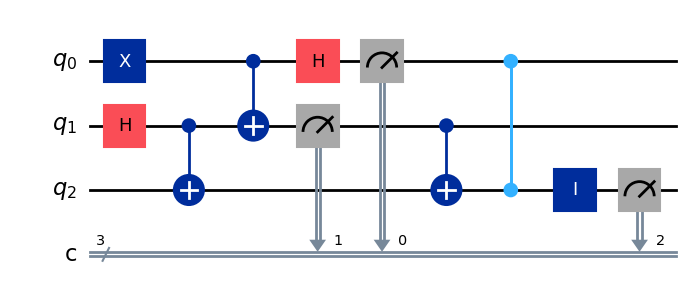

Teleportation Reliability (RT_u) = 0.9697


In [ ]:
# ============================================================
# Example Execution of RT_u Computation
# ============================================================

# tau → Quantum memory lifetime
# lam → Entanglement generation rate

tau = 8.0
lam = 15.0

# Compute teleportation reliability
RT_u = compute_RT(tau, lam)

print(f"Teleportation Reliability (RT_u) = {RT_u:.4f}")

In [ ]:
# ============================================================
# RH_u using 3-Qubit Redundancy with Majority Voting
# ============================================================

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error,
    thermal_relaxation_error
)

import numpy as np


def compute_RH(tau, lam,
               p_error=0.01,
               shots=1024,
               show_circuit=True):

    """
    Compute hop-by-hop reliability RH_u
    using repetition coding and majority voting
    """

    # ── 3-Qubit Redundancy Circuit ───────────────────────

    qc = QuantumCircuit(3, 3)

    qc.x(0)

    # Encode redundant copies
    qc.cx(0, 1)
    qc.cx(0, 2)

    # Idle gates for decoherence modeling
    qc.id(0)
    qc.id(1)
    qc.id(2)

    # Measurements
    qc.measure(0, 0)
    qc.measure(1, 1)
    qc.measure(2, 2)

    # ── Display Circuit ───────────────────────────────────

    if show_circuit:

        print("\n3-Qubit Redundancy Circuit:\n")

        try:
            display(qc.draw("mpl"))

        except:
            print(qc.draw())

    # ── Noise Model ───────────────────────────────────────

    noise_model = NoiseModel()

    # Gate depolarization noise
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(p_error, 1),
        ['x']
    )

    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(p_error, 2),
        ['cx']
    )

    # Memory decoherence noise
    T1 = tau
    T2 = tau / 2

    idle_time = 1.0 / lam

    thermal_error = thermal_relaxation_error(
        T1,
        T2,
        idle_time
    )

    noise_model.add_all_qubit_quantum_error(
        thermal_error,
        ['id']
    )

    # ── Run Simulation ────────────────────────────────────

    sim = AerSimulator(
        noise_model=noise_model,
        seed_simulator=42
    )

    result = sim.run(
        qc,
        shots=shots
    ).result()

    counts = result.get_counts()

    # ── Majority Voting ──────────────────────────────────

    success = 0

    for bits, count in counts.items():

        # Majority voting condition
        ones = bits.count('1')

        if ones >= 2:
            success += count

    RH = success / shots

    return RH


3-Qubit Redundancy Circuit:



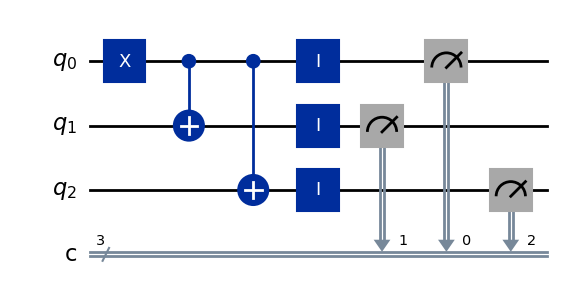

Hop-by-Hop Reliability (RH_u) = 0.9941


In [ ]:
# ============================================================
# Example Execution of RH_u Computation
# ============================================================

# tau → Quantum memory lifetime
# lam → Entanglement generation rate

tau = 8.0
lam = 15.0

# Compute hop-by-hop reliability
RH_u = compute_RH(tau, lam)

print(f"Hop-by-Hop Reliability (RH_u) = {RH_u:.4f}")

In [ ]:
# ============================================================
# Cache for Quantum-Computed RT_u and RH_u
# ============================================================

# Cache avoids repeated quantum circuit simulation
# for same (tau, lambda) values

RT_CACHE = {}
RH_CACHE = {}


def _cache_key(tau, lam):

    # Stable rounding to avoid float precision mismatch
    return (
        round(float(tau), 3),
        round(float(lam), 3)
    )


def get_RT(tau, lam):

    key = _cache_key(tau, lam)

    # Compute only if value not already stored
    if key not in RT_CACHE:

        RT_CACHE[key] = compute_RT(
            tau,
            lam,
            show_circuit=False
        )

    return RT_CACHE[key]


def get_RH(tau, lam):

    key = _cache_key(tau, lam)

    # Compute only if value not already stored
    if key not in RH_CACHE:

        RH_CACHE[key] = compute_RH(
            tau,
            lam,
            show_circuit=False
        )

    return RH_CACHE[key]

# Quantum Network Creation and Node Parameter Assignment

In [ ]:
# ============================================================
# Quantum Hardware Platform Definitions
# ============================================================

# Fixed random seed for reproducibility
np.random.seed(42)

# ── Hardware Platform Definitions ────────────────────────

# Each hardware platform has:
# tau_range    → Quantum memory lifetime range
# lambda_range → Entanglement generation rate range

HARDWARE_TYPES = {

    'superconducting': {

        'tau_range': (5.0, 10.0),

        'lambda_range': (20.0, 30.0),

        'description':
        'Fast entanglement generation, short memory lifetime'
    },

    'nv_center': {

        'tau_range': (8.0, 15.0),

        'lambda_range': (12.0, 20.0),

        'description':
        'Balanced memory and entanglement performance'
    },

    'trapped_ion': {

        'tau_range': (20.0, 40.0),

        'lambda_range': (5.0, 10.0),

        'description':
        'Long memory lifetime, slower entanglement generation'
    }
}

# ── Hardware Occurrence Distribution ─────────────────────

HARDWARE_DISTRIBUTION = {

    'superconducting': 0.40,

    'nv_center': 0.35,

    'trapped_ion': 0.25
}


# ── Random Hardware Assignment ───────────────────────────

def assign_hardware_type():

    rand = np.random.random()

    cumulative = 0.0

    for hw_type, prob in HARDWARE_DISTRIBUTION.items():

        cumulative += prob

        if rand < cumulative:
            return hw_type

    return 'nv_center'

In [ ]:
# ============================================================
# Assign Quantum-Aware Parameters to Network Nodes
# ============================================================

def assign_node_parameters_quantum(G, bifunctional_prob=0.85):

    for node in G.nodes():

        # ── Node Type Assignment ──────────────────────────

        is_bi = np.random.rand() < bifunctional_prob

        G.nodes[node]['type'] = (
            'bi' if is_bi else 'mono'
        )

        # ── Hardware Assignment ───────────────────────────

        hw_type = assign_hardware_type()

        G.nodes[node]['hardware'] = hw_type

        hw = HARDWARE_TYPES[hw_type]

        # ── Quantum Memory & Entanglement Parameters ─────

        tau = np.random.uniform(*hw['tau_range'])
        lam = np.random.uniform(*hw['lambda_range'])

        G.nodes[node]['tau'] = tau
        G.nodes[node]['lambda'] = lam

        # Entanglement waiting time
        G.nodes[node]['W'] = 1.0 / lam

        # ── Quantum-derived Reliability Values ───────────

        RT_base = get_RT(tau, lam)
        RH_base = get_RH(tau, lam)

        # ── Controlled Competition Between Modes ─────────

        delta = np.random.uniform(0.01, 0.03)

        if np.random.rand() < 0.5:

            # Teleportation-favored node
            RT = min(0.995, RT_base + delta)
            RH = max(0.94, RH_base - delta/2)

        else:

            # H2H-favored node
            RH = min(0.995, RH_base + delta)
            RT = max(0.94, RT_base - delta/2)

        G.nodes[node]['RT'] = RT
        G.nodes[node]['RH'] = RH

        # ── Processing Delays ────────────────────────────

        G.nodes[node]['PT'] = np.random.uniform(0.3, 1.0)

        # H2H includes additional processing overhead
        G.nodes[node]['PH'] = (
            np.random.uniform(0.2, 0.9)
            + np.random.uniform(0.05, 0.15)
        )

    # ── Global Reliability Balancing ─────────────────────

    avg_RT = np.mean([
        G.nodes[n]['RT']
        for n in G.nodes()
    ])

    avg_RH = np.mean([
        G.nodes[n]['RH']
        for n in G.nodes()
    ])

    # Prevent one routing mode from dominating globally
    if abs(avg_RT - avg_RH) > 0.005:

        for n in G.nodes():

            G.nodes[n]['RT'] *= 0.995
            G.nodes[n]['RH'] *= 0.995

    # ── Edge Weight Assignment ───────────────────────────

    for u, v in G.edges():

        # Lower weight → faster entanglement generation
        G[u][v]['weight'] = (
            1 / G.nodes[u]['lambda']
        )

    return G


>>> LINE GRAPH
Line Graph
Node  Type  HW         RT     RH     PT     PH      τ      λ      W
--------------------------------------------------------------------------------
0     bi    supe    0.962  0.990  0.684  0.428  8.859 20.864  0.048
1     bi    trap    0.962  0.990  0.401  0.777 35.754  8.122  0.123
2     bi    supe    0.985  0.982  0.804  0.551  9.735 29.674  0.034
3     bi    nv_c    0.961  0.990  0.854  0.695 14.864 13.819  0.072
4     bi    trap    0.990  0.978  0.368  0.899 28.573  5.705  0.175
5     bi    supe    0.961  0.990  0.856  0.632  8.935 21.119  0.047
6     mono  nv_c    0.982  0.984  0.762  0.389 13.309 18.033  0.055
7     mono  nv_c    0.990  0.978  0.541  0.487 13.255 16.464  0.061
8     bi    supe    0.982  0.983  0.437  0.390  7.258 23.974  0.042
9     bi    trap    0.990  0.978  0.928  0.659 25.529  6.562  0.152

>>> GENERAL GRAPH
General Graph
Node  Type  HW         RT     RH     PT     PH      τ      λ      W
-------------------------------------------

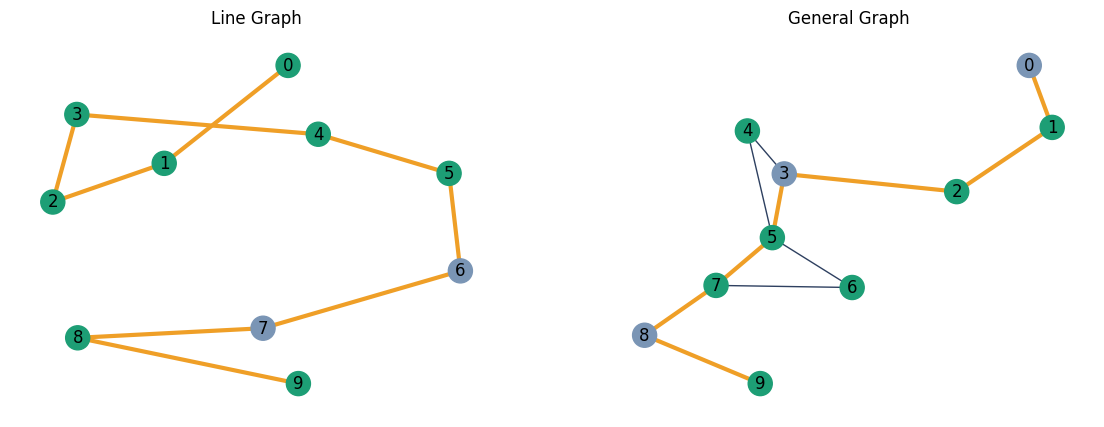

In [ ]:
# ============================================================
# Quantum Network Graph Creation and Visualization
# ============================================================

# ── Line Graph Generation ────────────────────────────────

def create_line_graph(num_nodes,
                      bifunctional_prob=0.85):

    # Create simple path-based topology
    G = nx.path_graph(num_nodes)

    # Assign quantum-aware node parameters
    G = assign_node_parameters_quantum(
        G,
        bifunctional_prob
    )

    return G, list(range(num_nodes))


# ── General Graph Generation ─────────────────────────────

def create_general_graph(num_nodes,
                         extra_edges=2,
                         bifunctional_prob=0.85):

    """
    Controlled graph generation:
    - Long routing path
    - Limited shortcut edges
    - Stable QAOA optimization
    """

    # Start with line topology
    G = nx.path_graph(num_nodes)

    # Add limited local shortcut edges
    added = 0
    attempts = 0

    while added < extra_edges and attempts < 50:

        u = np.random.randint(0, num_nodes)
        v = np.random.randint(0, num_nodes)

        # Avoid excessive path shortening
        if (
            u != v
            and not G.has_edge(u, v)
            and abs(u - v) <= 2
        ):

            G.add_edge(u, v)

            added += 1

        attempts += 1

    # Assign quantum-aware parameters
    G = assign_node_parameters_quantum(
        G,
        bifunctional_prob
    )

    # Compute shortest routing path
    path = nx.dijkstra_path(
        G,
        0,
        num_nodes - 1,
        weight='weight'
    )

    return G, path


# ── Display Network Parameters ───────────────────────────

def display_network(G, path, title):

    print("=" * 80)
    print(title)
    print("=" * 80)

    print(f"{'Node':<5} {'Type':<5} {'HW':<6} "
          f"{'RT':>6} {'RH':>6} "
          f"{'PT':>6} {'PH':>6} "
          f"{'τ':>6} {'λ':>6} {'W':>6}")

    print("-" * 80)

    for node in path:

        d = G.nodes[node]

        print(f"{node:<5} "
              f"{d['type']:<5} "
              f"{d['hardware'][:4]:<6} "
              f"{d['RT']:>6.3f} "
              f"{d['RH']:>6.3f} "
              f"{d['PT']:>6.3f} "
              f"{d['PH']:>6.3f} "
              f"{d['tau']:>6.3f} "
              f"{d['lambda']:>6.3f} "
              f"{d['W']:>6.3f}")

    print("=" * 80)


# ── Graph Visualization ──────────────────────────────────

def plot_graph(G, path, ax, title):

    pos = nx.spring_layout(G, seed=42)

    # Node colors
    node_colors = [
        '#1D9E75'
        if G.nodes[n]['type'] == 'bi'
        else '#7A95B5'
        for n in G.nodes()
    ]

    # Highlight routing path
    path_edges = list(zip(path[:-1], path[1:]))

    edge_colors = [
        '#EF9F27'
        if e in path_edges or (e[1], e[0]) in path_edges
        else '#2E4060'
        for e in G.edges()
    ]

    edge_widths = [
        3
        if e in path_edges or (e[1], e[0]) in path_edges
        else 1
        for e in G.edges()
    ]

    nx.draw(
        G,
        pos,
        ax=ax,
        node_color=node_colors,
        edge_color=edge_colors,
        width=edge_widths,
        with_labels=True
    )

    ax.set_title(title)
    ax.axis('off')

# ── Fixed Seed for Reproducibility ───────────────────────

# np.random.seed(42)


# ── Create Quantum Networks ──────────────────────────────

G_line, path_line = create_line_graph(
    10,
    bifunctional_prob=0.85
)

G_gen, path_gen = create_general_graph(
    10,
    extra_edges=2,
    bifunctional_prob=0.85
)

# ── Display Network Details ──────────────────────────────

print("\n>>> LINE GRAPH")

display_network(
    G_line,
    path_line,
    "Line Graph"
)

print("\n>>> GENERAL GRAPH")

display_network(
    G_gen,
    path_gen,
    "General Graph"
)

# ── Plot Graphs ──────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_graph(
    G_line,
    path_line,
    axes[0],
    "Line Graph"
)

plot_graph(
    G_gen,
    path_gen,
    axes[1],
    "General Graph"
)

plt.show()

# Routing Algorithms

In [ ]:
# ============================================================
# Teleportation-Only Baseline Algorithm
# ============================================================

def teleportation_only(G, path):

    """
    Baseline routing strategy:
    All nodes use teleportation mode only
    """

    # End-to-end reliability
    Rse = 1.0

    # Total transmission delay
    total_time = 0.0

    # Mode assignment for each node
    mode_assignment = []

    # ── Traverse Routing Path ────────────────────────────

    for node in path:

        d = G.nodes[node]

        # Always select teleportation
        Rse *= d['RT']

        total_time += d['PT']

        mode_assignment.append('T')

    return Rse, total_time, mode_assignment


# ============================================================
# Result Display Function
# ============================================================

def display_result(G,
                   path,
                   Rse,
                   total_time,
                   mode_assignment,
                   title):

    print("=" * 60)

    print(f"  {title}")

    print("=" * 60)

    print(f"  {'Node':<8} "
          f"{'Mode':<8} "
          f"{'R used':>8} "
          f"{'Time':>8}")

    print("-" * 60)

    for i, node in enumerate(path):

        d = G.nodes[node]

        mode = mode_assignment[i]

        # Selected reliability and delay
        if mode == 'T':

            r = d['RT']
            t = d['PT']

        else:

            r = d['RH']
            t = d['PH']

        print(f"  {node:<8} "
              f"{mode:<8} "
              f"{r:>8.4f} "
              f"{t:>8.4f}")

    print("-" * 60)

    print(f"  End-to-end Reliability (Rse) : "
          f"{Rse:.6f}")

    print(f"  Total Transmission Time      : "
          f"{total_time:.4f}")

    print(f"  Mode Assignment              : "
          f"{mode_assignment}")

    print("=" * 60)


# ============================================================
# Run Teleportation-Only Routing
# ============================================================

# ── Line Graph ───────────────────────────────────────────

Rse_line, time_line, modes_line = teleportation_only(
    G_line,
    path_line
)

display_result(
    G_line,
    path_line,
    Rse_line,
    time_line,
    modes_line,
    "Teleportation-Only — Line Graph"
)

print()

# ── General Graph ───────────────────────────────────────

Rse_gen, time_gen, modes_gen = teleportation_only(
    G_gen,
    path_gen
)

display_result(
    G_gen,
    path_gen,
    Rse_gen,
    time_gen,
    modes_gen,
    "Teleportation-Only — General Graph"
)

  Teleportation-Only — Line Graph
  Node     Mode       R used     Time
------------------------------------------------------------
  0        T          0.9624   0.6838
  1        T          0.9618   0.4015
  2        T          0.9853   0.8040
  3        T          0.9607   0.8542
  4        T          0.9900   0.3683
  5        T          0.9612   0.8558
  6        T          0.9820   0.7617
  7        T          0.9900   0.5406
  8        T          0.9815   0.4369
  9        T          0.9900   0.9279
------------------------------------------------------------
  End-to-end Reliability (Rse) : 0.787726
  Total Transmission Time      : 6.6347
  Mode Assignment              : ['T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T']

  Teleportation-Only — General Graph
  Node     Mode       R used     Time
------------------------------------------------------------
  0        T          0.9616   0.6398
  1        T          0.9654   0.3651
  2        T          0.9638   0.3775
  3      

In [ ]:
# ============================================================
# Base Paper Greedy Routing Algorithm
# ============================================================

def greedy_base(G, path):

    """
    Greedy routing optimization based on
    the base paper Algorithm 1
    """

    # End-to-end reliability
    Rse = 1.0

    # Total transmission delay
    total_time = 0.0

    # Routing mode selected at each node
    mode_assignment = []

    # ── Traverse Routing Path ────────────────────────────

    for i, node in enumerate(path):

        d = G.nodes[node]

        RT_u = d['RT']
        RH_u = d['RH']

        PT_u = d['PT']
        PH_u = d['PH']

        # Next node in routing path
        next_node = (
            path[i + 1]
            if i + 1 < len(path)
            else None
        )

        current_is_mono = (
            d['type'] == 'mono'
        )

        next_is_mono = (
            G.nodes[next_node]['type'] == 'mono'
            if next_node is not None
            else False
        )

        # ── Case 1: Forced Teleportation ────────────────

        if current_is_mono or next_is_mono:

            mode = 'T'

            Rse *= RT_u

            total_time += PT_u

        # ── Case 2: Both Nodes are Bi-functional ───────

        else:

            # Select higher reliability mode
            if RT_u >= RH_u:

                # Tie-breaking using delay
                if RT_u == RH_u and PT_u > PH_u:

                    mode = 'H2H'

                    Rse *= RH_u

                    total_time += PH_u

                else:

                    mode = 'T'

                    Rse *= RT_u

                    total_time += PT_u

            else:

                mode = 'H2H'

                Rse *= RH_u

                total_time += PH_u

        mode_assignment.append(mode)

    return Rse, total_time, mode_assignment


# ============================================================
# Result Display Function
# ============================================================

def display_result_v2(G, path,
                      Rse,
                      total_time,
                      mode_assignment,
                      title):

    print("=" * 65)

    print(f"  {title}")

    print("=" * 65)

    print(f"  {'Node':<6} "
          f"{'Type':<6} "
          f"{'Mode':<6} "
          f"{'R used':>8} "
          f"{'T used':>8} "
          f"{'Reff':>8}")

    print("-" * 65)

    running_Rse = 1.0

    for i, node in enumerate(path):

        d = G.nodes[node]

        # mode = mode_assignment[i]
        mode = mode_assignment[i] if i < len(mode_assignment) else 'T'

        # Selected reliability and delay
        if mode == 'T':

            r = d['RT']
            t = d['PT']

        else:

            r = d['RH']
            t = d['PH']

        running_Rse *= r

        print(f"  {node:<6} "
              f"{d['type']:<6} "
              f"{mode:<6} "
              f"{r:>8.4f} "
              f"{t:>8.4f} "
              f"{running_Rse:>8.4f}")

    print("-" * 65)

    print(f"  End-to-end Reliability (Rse) : {Rse:.6f}")

    print(f"  Total Transmission Time      : {total_time:.4f}")

    print(f"  Mode Assignment              : {mode_assignment}")

    print("=" * 65)


# ============================================================
# Run Greedy Routing Optimization
# ============================================================

Rse_g_line, time_g_line, modes_g_line = greedy_base(
    G_line,
    path_line
)

display_result_v2(
    G_line,
    path_line,
    Rse_g_line,
    time_g_line,
    modes_g_line,
    "Base Paper Greedy — Line Graph"
)

print()

Rse_g_gen, time_g_gen, modes_g_gen = greedy_base(
    G_gen,
    path_gen
)

display_result_v2(
    G_gen,
    path_gen,
    Rse_g_gen,
    time_g_gen,
    modes_g_gen,
    "Base Paper Greedy — General Graph"
)

print()

# ============================================================
# Performance Comparison
# ============================================================

print("=" * 65)

print("  COMPARISON — Line Graph")

print("=" * 65)

print(f"  Teleportation-Only : "
      f"Rse = {Rse_line:.6f}  "
      f"Time = {time_line:.4f}")

print(f"  Base Greedy        : "
      f"Rse = {Rse_g_line:.6f}  "
      f"Time = {time_g_line:.4f}")

improvement = (
    (Rse_g_line - Rse_line)
    / Rse_line
) * 100

print(f"  Improvement        : "
      f"{improvement:+.2f}%")

print("=" * 65)

  Base Paper Greedy — Line Graph
  Node   Type   Mode     R used   T used     Reff
-----------------------------------------------------------------
  0      bi     H2H      0.9900   0.4278   0.9900
  1      bi     H2H      0.9900   0.7767   0.9801
  2      bi     T        0.9853   0.8040   0.9657
  3      bi     H2H      0.9900   0.6955   0.9561
  4      bi     T        0.9900   0.3683   0.9465
  5      bi     T        0.9612   0.8558   0.9098
  6      mono   T        0.9820   0.7617   0.8934
  7      mono   T        0.9900   0.5406   0.8845
  8      bi     H2H      0.9833   0.3901   0.8697
  9      bi     T        0.9900   0.9279   0.8611
-----------------------------------------------------------------
  End-to-end Reliability (Rse) : 0.861057
  Total Transmission Time      : 6.5484
  Mode Assignment              : ['H2H', 'H2H', 'T', 'H2H', 'T', 'T', 'T', 'T', 'H2H', 'T']

  Base Paper Greedy — General Graph
  Node   Type   Mode     R used   T used     Reff
------------------------

In [ ]:
# ============================================================
# MRAG — Memory & Rate Aware Greedy Algorithm
# ============================================================

import numpy as np


def mrag(G, path):

    """
    Memory & Rate Aware Greedy Routing

    Improvements over base greedy:
    - Considers quantum memory decay
    - Considers entanglement waiting time
    - Uses effective reliability (R_eff)
    """

    # End-to-end reliability
    Rse = 1.0

    # Total transmission delay
    cumulative_time = 0.0

    # Mode assignment along routing path
    mode_assignment = []

    # Store detailed routing statistics
    details = []

    # ── Traverse Routing Path ────────────────────────────

    for i, node in enumerate(path):

        d = G.nodes[node]

        RT = d['RT']
        RH = d['RH']

        PT = d['PT']
        PH = d['PH']

        tau = d['tau']
        lam = d['lambda']

        # Entanglement waiting time
        W = 1.0 / lam

        next_node = (
            path[i + 1]
            if i + 1 < len(path)
            else None
        )

        current_is_mono = (
            d['type'] == 'mono'
        )

        next_is_mono = (
            G.nodes[next_node]['type'] == 'mono'
            if next_node
            else False
        )

        # ── Teleportation Effective Reliability ─────────

        delta_T_T = PT + W

        decay_T = np.exp(
            -0.3*delta_T_T / tau
        )

        Reff_T = RT * decay_T

        # ── H2H Effective Reliability ───────────────────

        delta_T_H = PH

        decay_H = np.exp(
            -0.3*delta_T_H / tau
        )

        Reff_H = RH * decay_H

        # ── Routing Mode Selection ──────────────────────

        # Mono-functional nodes force teleportation
        if current_is_mono or next_is_mono:

            mode = 'T'

            R_used = Reff_T

            T_used = delta_T_T

        else:

            # Select mode with higher effective reliability
            if Reff_T >= Reff_H:

                mode = 'T'

                R_used = Reff_T

                T_used = delta_T_T

            else:

                mode = 'H2H'

                R_used = Reff_H

                T_used = delta_T_H

        # ── Update Global Metrics ───────────────────────

        cumulative_time += T_used

        Rse *= R_used

        mode_assignment.append(mode)

        # Store detailed node statistics
        details.append({

            'node': node,

            'type': d['type'],

            'mode': mode,

            'RT': RT,

            'RH': RH,

            'tau': tau,

            'lambda': lam,

            'W': W,

            'Reff_T': Reff_T,

            'Reff_H': Reff_H,

            'R_used': R_used,

            'T_used': T_used,

            'cum_time': cumulative_time,

            'Rse_run': Rse
        })

    return (
        Rse,
        cumulative_time,
        mode_assignment,
        details
    )

In [ ]:
# ============================================================
# MRAG Results and Performance Comparison
# ============================================================

# ── Run MRAG Routing ─────────────────────────────────────

Rse_mrag_line, time_mrag_line, \
modes_mrag_line, details_line = mrag(
    G_line,
    path_line
)

Rse_mrag_gen, time_mrag_gen, \
modes_mrag_gen, details_gen = mrag(
    G_gen,
    path_gen
)


# ============================================================
# MRAG Result Display Function
# ============================================================

def display_mrag_v2(G,
                    path,
                    Rse,
                    total_time,
                    modes,
                    title):

    print("=" * 70)

    print(f"  {title}")

    print("=" * 70)

    print(f"  {'Node':<6} "
          f"{'Type':<6} "
          f"{'Mode':<6} "
          f"{'R used':>8} "
          f"{'T used':>8} "
          f"{'Reff':>8}")

    print("-" * 70)

    running_Rse = 1.0

    for i, node in enumerate(path):

        d = G.nodes[node]

        mode = modes[i]

        RT = d['RT']
        RH = d['RH']

        PT = d['PT']
        PH = d['PH']

        tau = d['tau']

        lam = d['lambda']

        W = d['W']

        # Recompute effective reliability
        if mode == 'T':

            delta_T = PT + W

            decay = np.exp(
                -0.3*delta_T / tau
            )

            r = RT * decay

            t = delta_T

        else:

            delta_T = PH

            decay = np.exp(
                -0.3*delta_T / tau
            )

            r = RH * decay

            t = PH

        running_Rse *= r

        print(f"  {node:<6} "
              f"{d['type']:<6} "
              f"{mode:<6} "
              f"{r:>8.4f} "
              f"{t:>8.4f} "
              f"{running_Rse:>8.4f}")

    print("-" * 70)

    print(f"  End-to-end Reliability (Rse) : "
          f"{Rse:.6f}")

    print(f"  Total Transmission Time      : "
          f"{total_time:.4f}")

    print(f"  Mode Assignment              : "
          f"{modes}")

    print("=" * 70)


# ============================================================
# Display MRAG Results
# ============================================================

display_mrag_v2(
    G_line,
    path_line,
    Rse_mrag_line,
    time_mrag_line,
    modes_mrag_line,
    "MRAG — Line Graph"
)

print()

display_mrag_v2(
    G_gen,
    path_gen,
    Rse_mrag_gen,
    time_mrag_gen,
    modes_mrag_gen,
    "MRAG — General Graph"
)

print()


# ============================================================
# Comparison: Base Greedy vs MRAG
# ============================================================

print("=" * 75)

print("  COMPARISON — Base Greedy vs MRAG")

print("=" * 75)

print(f"{'Algorithm':<25} "
      f"{'Rse':>10} "
      f"{'Time':>10}")

print("-" * 75)

print(f"{'Base Greedy':<25} "
      f"{Rse_g_line:>10.6f} "
      f"{time_g_line:>10.4f}")

print(f"{'MRAG':<25} "
      f"{Rse_mrag_line:>10.6f} "
      f"{time_mrag_line:>10.4f}")

print("-" * 75)

drop = (
    (Rse_g_line - Rse_mrag_line)
    / Rse_g_line
) * 100

print(f"  Reliability Change : "
      f"{drop:.2f}%")

print("=" * 75)

  MRAG — Line Graph
  Node   Type   Mode     R used   T used     Reff
----------------------------------------------------------------------
  0      bi     H2H      0.9758   0.4278   0.9758
  1      bi     H2H      0.9836   0.7767   0.9598
  2      bi     H2H      0.9658   0.5515   0.9270
  3      bi     H2H      0.9762   0.6955   0.9049
  4      bi     T        0.9844   0.5436   0.8908
  5      bi     T        0.9325   0.9031   0.8307
  6      mono   T        0.9641   0.8172   0.8008
  7      mono   T        0.9766   0.6013   0.7821
  8      bi     H2H      0.9675   0.3901   0.7567
  9      bi     T        0.9775   1.0803   0.7397
----------------------------------------------------------------------
  End-to-end Reliability (Rse) : 0.739741
  Total Transmission Time      : 6.7871
  Mode Assignment              : ['H2H', 'H2H', 'H2H', 'H2H', 'T', 'T', 'T', 'T', 'H2H', 'T']

  MRAG — General Graph
  Node   Type   Mode     R used   T used     Reff
--------------------------------------

In [ ]:
# ============================================================
# Base Paper Dynamic Programming Algorithm
# ============================================================

def dp_base(G, path, T_constraint):

    """
    Dynamic Programming Routing Optimization

    Features:
    - Maximizes routing reliability
    - Enforces transmission time constraint
    - Explores both routing modes globally
    """

    n = len(path)

    # Time discretization step
    time_step = 0.01

    T_steps = int(
        T_constraint / time_step
    )

    # DP table:
    # caching[i][t] = best solution
    caching = [
        [None] * (T_steps + 1)
        for _ in range(n)
    ]

    # ── Base Case ────────────────────────────────────────

    for t_step in range(T_steps + 1):

        caching[n - 1][t_step] = (
            1.0,
            []
        )

    # ── Bottom-Up DP Computation ────────────────────────

    for i in range(n - 2, -1, -1):

        node = path[i]

        next_node = path[i + 1]

        d = G.nodes[node]

        d_next = G.nodes[next_node]

        RT_u = d['RT']
        RH_u = d['RH']

        PT_u = d['PT']
        PH_u = d['PH']

        PT_steps = int(
            PT_u / time_step
        )

        PH_steps = int(
            PH_u / time_step
        )

        current_is_mono = (
            d['type'] == 'mono'
        )

        next_is_mono = (
            d_next['type'] == 'mono'
        )

        for t_step in range(T_steps + 1):

            best_Rse = 0.0

            best_modes = None

            # ── Try Teleportation ───────────────────────

            remaining_T = (
                t_step - PT_steps
            )

            if (
                remaining_T >= 0
                and caching[i + 1][remaining_T]
                is not None
            ):

                Rse_next, modes_next = \
                    caching[i + 1][remaining_T]

                Rse_T = RT_u * Rse_next

                if Rse_T > best_Rse:

                    best_Rse = Rse_T

                    best_modes = (
                        ['T'] + modes_next
                    )

            # ── Try H2H Routing ─────────────────────────

            if (
                not current_is_mono
                and not next_is_mono
            ):

                remaining_H = (
                    t_step - PH_steps
                )

                if (
                    remaining_H >= 0
                    and caching[i + 1][remaining_H]
                    is not None
                ):

                    Rse_next, modes_next = \
                        caching[i + 1][remaining_H]

                    Rse_H = RH_u * Rse_next

                    if Rse_H > best_Rse:

                        best_Rse = Rse_H

                        best_modes = (
                            ['H2H'] + modes_next
                        )

            if best_modes is not None:

                caching[i][t_step] = (
                    best_Rse,
                    best_modes
                )

    # ── Extract Optimal Solution ────────────────────────

    best_Rse = 0.0

    best_time = 0.0

    best_modes = []

    for t_step in range(T_steps + 1):

        if caching[0][t_step] is not None:

            Rse, modes = caching[0][t_step]

            if Rse > best_Rse:

                best_Rse = Rse

                best_time = (
                    t_step * time_step
                )

                best_modes = modes

    # Destination alignment
    best_modes = best_modes + ['T']

    return (
        best_Rse,
        best_time,
        best_modes
    )


# ============================================================
# Run Dynamic Programming Optimization
# ============================================================

T = 20.0

# ── Line Graph ───────────────────────────────────────────

Rse_dp_line, time_dp_line, \
modes_dp_line = dp_base(
    G_line,
    path_line,
    T
)

display_result_v2(
    G_line,
    path_line,
    Rse_dp_line,
    time_dp_line,
    modes_dp_line,
    f"Base Paper DP — Line Graph (T={T})"
)

print()

# ── General Graph ───────────────────────────────────────

Rse_dp_gen, time_dp_gen, \
modes_dp_gen = dp_base(
    G_gen,
    path_gen,
    T
)

display_result_v2(
    G_gen,
    path_gen,
    Rse_dp_gen,
    time_dp_gen,
    modes_dp_gen,
    f"Base Paper DP — General Graph (T={T})"
)

print()


# ============================================================
# Performance Comparison
# ============================================================

print("=" * 65)

print("  FULL COMPARISON — Line Graph")

print("=" * 65)

print(f"  Teleportation-Only : "
      f"Rse = {Rse_line:.6f}  "
      f"Time = {time_line:.4f}")

print(f"  Base Greedy        : "
      f"Rse = {Rse_g_line:.6f}  "
      f"Time = {time_g_line:.4f}")

print(f"  Base DP (T={T})    : "
      f"Rse = {Rse_dp_line:.6f}  "
      f"Time = {time_dp_line:.4f}")

print("-" * 65)

imp_greedy = (
    (Rse_g_line - Rse_line)
    / Rse_line
) * 100

imp_dp = (
    (Rse_dp_line - Rse_line)
    / Rse_line
) * 100

print(f"  Greedy Improvement : "
      f"{imp_greedy:+.2f}%")

print(f"  DP Improvement     : "
      f"{imp_dp:+.2f}%")

print("=" * 65)

  Base Paper DP — Line Graph (T=20.0)
  Node   Type   Mode     R used   T used     Reff
-----------------------------------------------------------------
  0      bi     H2H      0.9900   0.4278   0.9900
  1      bi     H2H      0.9900   0.7767   0.9801
  2      bi     T        0.9853   0.8040   0.9657
  3      bi     H2H      0.9900   0.6955   0.9561
  4      bi     T        0.9900   0.3683   0.9465
  5      bi     T        0.9612   0.8558   0.9098
  6      mono   T        0.9820   0.7617   0.8934
  7      mono   T        0.9900   0.5406   0.8845
  8      bi     H2H      0.9833   0.3901   0.8697
  9      bi     T        0.9900   0.9279   0.8611
-----------------------------------------------------------------
  End-to-end Reliability (Rse) : 0.869733
  Total Transmission Time      : 5.5800
  Mode Assignment              : ['H2H', 'H2H', 'T', 'H2H', 'T', 'T', 'T', 'T', 'H2H', 'T']

  Base Paper DP — General Graph (T=20.0)
  Node   Type   Mode     R used   T used     Reff
--------------

In [ ]:
# ============================================================
# MRADP — Memory & Rate Aware Dynamic Programming
# ============================================================

def mradp(G, path, T_constraint):

    """
    Memory & Rate Aware Dynamic Programming

    Features:
    - Considers memory decoherence
    - Considers entanglement waiting delay
    - Enforces transmission time constraint
    - Globally optimizes routing reliability
    """

    import numpy as np

    n = len(path)

    # Time discretization step
    time_step = 0.01

    T_steps = int(
        T_constraint / time_step
    )

    # DP table:
    # caching[i][t] = best solution
    caching = [
        [None] * (T_steps + 1)
        for _ in range(n)
    ]

    # ── Base Case ────────────────────────────────────────

    for t in range(T_steps + 1):

        caching[n - 1][t] = (
            1.0,
            []
        )

    # ── Bottom-Up DP Computation ────────────────────────

    for i in range(n - 2, -1, -1):

        node = path[i]

        next_node = path[i + 1]

        d = G.nodes[node]

        d_next = G.nodes[next_node]

        RT = d['RT']
        RH = d['RH']

        PT = d['PT']
        PH = d['PH']

        tau = d['tau']

        lam = d['lambda']

        # Entanglement waiting delay
        W = 1.0 / lam

        PT_steps = int(
            (PT + W) / time_step
        )

        PH_steps = int(
            PH / time_step
        )

        current_is_mono = (
            d['type'] == 'mono'
        )

        next_is_mono = (
            d_next['type'] == 'mono'
        )

        for t in range(T_steps + 1):

            best_Rse = 0.0

            best_modes = None

            # ── Try Teleportation ───────────────────────

            rem_T = t - PT_steps

            if (
                rem_T >= 0
                and caching[i + 1][rem_T]
                is not None
            ):

                R_next, modes_next = \
                    caching[i + 1][rem_T]

                delta_T = PT + W

                decay = np.exp(
                    -0.3 * delta_T / tau
                )

                R_T = RT * decay * R_next

                if R_T > best_Rse:

                    best_Rse = R_T

                    best_modes = (
                        ['T'] + modes_next
                    )

            # ── Try H2H Routing ─────────────────────────

            if (
                not current_is_mono
                and not next_is_mono
            ):

                rem_H = t - PH_steps

                if (
                    rem_H >= 0
                    and caching[i + 1][rem_H]
                    is not None
                ):

                    R_next, modes_next = \
                        caching[i + 1][rem_H]

                    delta_T = PH

                    decay = np.exp(
                        -0.3 * delta_T / tau
                    )

                    R_H = RH * decay * R_next

                    if R_H > best_Rse:

                        best_Rse = R_H

                        best_modes = (
                            ['H2H'] + modes_next
                        )

            if best_modes is not None:

                caching[i][t] = (
                    best_Rse,
                    best_modes
                )

    # ── Extract Optimal Solution ────────────────────────

    best_Rse = 0.0

    best_time = 0.0

    best_modes = []

    for t in range(T_steps + 1):

        if caching[0][t] is not None:

            R, modes = caching[0][t]

            if R > best_Rse:

                best_Rse = R

                best_time = (
                    t * time_step
                )

                best_modes = modes

    # Destination alignment
    best_modes = best_modes + ['T']

    return (
        best_Rse,
        best_time,
        best_modes
    )

In [ ]:
# ============================================================
# MRADP Results and Performance Comparison
# ============================================================

# ── Run MRADP Optimization ──────────────────────────────

T = 5.0

# Rse_mradp_line, time_mradp_line, \
# modes_mradp_line = mradp(
#     G_line,
#     path_line,
#     T
# )

Rse_mradp_gen, time_mradp_gen, \
modes_mradp_gen = mradp(
    G_gen,
    path_gen,
    T
)


# ============================================================
# Display MRADP Results
# ============================================================

# display_result_v2(
#     G_line,
#     path_line,
#     Rse_mradp_line,
#     time_mradp_line,
#     modes_mradp_line,
#     f"MRADP — Line Graph (T={T})"
# )

# print()

display_result_v2(
    G_gen,
    path_gen,
    Rse_mradp_gen,
    time_mradp_gen,
    modes_mradp_gen,
    f"MRADP — General Graph (T={T})"
)

print()


# # ============================================================
# # Comparison: Base DP vs MRADP
# # ============================================================

# print("=" * 70)

# print("  COMPARISON — Base DP vs MRADP")

# print("=" * 70)

# print(f"{'Algorithm':<20} "
#       f"{'Rse':>10} "
#       f"{'Time':>8}")

# print("-" * 70)

# print(f"{'Base DP':<20} "
#       f"{Rse_dp_line:>10.6f} "
#       f"{time_dp_line:>8.4f}")

# print(f"{'MRADP':<20} "
#       f"{Rse_mradp_line:>10.6f} "
#       f"{time_mradp_line:>8.4f}")

# print("-" * 70)

# adjustment = (
#     (Rse_dp_line - Rse_mradp_line)
#     / Rse_dp_line
# ) * 100

# print(f"  Reliability Adjustment : "
#       f"{adjustment:+.2f}%")

# print("=" * 70)

# print()


# ============================================================
# General Graph Comparison
# ============================================================

print("=" * 70)

print("  GENERAL GRAPH COMPARISON")

print("=" * 70)

print(f"{'Algorithm':<20} "
      f"{'Rse':>10} "
      f"{'Time':>8}")

print("-" * 70)

print(f"{'Base DP':<20} "
      f"{Rse_dp_gen:>10.6f} "
      f"{time_dp_gen:>8.4f}")

print(f"{'MRADP':<20} "
      f"{Rse_mradp_gen:>10.6f} "
      f"{time_mradp_gen:>8.4f}")

print("-" * 70)

adjustment_gen = (
    (Rse_dp_gen - Rse_mradp_gen)
    / Rse_dp_gen
) * 100

print(f"  Reliability Adjustment : "
      f"{adjustment_gen:+.2f}%")

print("=" * 70)

  MRADP — General Graph (T=5.0)
  Node   Type   Mode     R used   T used     Reff
-----------------------------------------------------------------
  0      mono   T        0.9616   0.6398   0.9616
  1      bi     H2H      0.9900   0.3529   0.9520
  2      bi     T        0.9638   0.3775   0.9175
  3      mono   T        0.9556   0.6678   0.8768
  5      bi     H2H      0.9900   0.4708   0.8680
  7      bi     T        0.9582   0.4629   0.8317
  8      mono   T        0.9831   0.5657   0.8176
  9      bi     T        0.9810   0.3190   0.8021
-----------------------------------------------------------------
  End-to-end Reliability (Rse) : 0.753185
  Total Transmission Time      : 3.8600
  Mode Assignment              : ['T', 'H2H', 'T', 'T', 'H2H', 'T', 'T', 'T']

  GENERAL GRAPH COMPARISON
Algorithm                   Rse     Time
----------------------------------------------------------------------
Base DP                0.817637   3.5000
MRADP                  0.753185   3.8600
----

In [ ]:
# ============================================================
# Final Comparison of All Routing Algorithms
# ============================================================

# Time constraint for DP-based algorithms
T = 10.0

print("=" * 65)

print("FINAL COMPARISON — GENERAL GRAPH")

print("=" * 65)

# ============================================================
# Run All Routing Algorithms
# ============================================================

# Teleportation-only baseline
Rse_t, time_t, _ = teleportation_only(
    G_gen,
    path_gen
)

# Base Greedy
Rse_g, time_g, _ = greedy_base(
    G_gen,
    path_gen
)

# Base Dynamic Programming
Rse_dp, time_dp, _ = dp_base(
    G_gen,
    path_gen,
    T
)

# Memory & Rate Aware Greedy
Rse_mrag, time_mrag, _, _ = mrag(
    G_gen,
    path_gen
)

# Memory & Rate Aware Dynamic Programming
Rse_mradp, time_mradp, _ = mradp(
    G_gen,
    path_gen,
    T
)


# ============================================================
# Performance Comparison Table
# ============================================================

print(f"{'Algorithm':<22} "
      f"{'Rse':>10} "
      f"{'Time':>10}")

print("-" * 65)

print(f"{'Teleportation':<22} "
      f"{Rse_t:>10.6f} "
      f"{time_t:>10.4f}")

print(f"{'Base Greedy':<22} "
      f"{Rse_g:>10.6f} "
      f"{time_g:>10.4f}")

print(f"{'Base DP':<22} "
      f"{Rse_dp:>10.6f} "
      f"{time_dp:>10.4f}")

print(f"{'MRAG':<22} "
      f"{Rse_mrag:>10.6f} "
      f"{time_mrag:>10.4f}")

print(f"{'MRADP':<22} "
      f"{Rse_mradp:>10.6f} "
      f"{time_mradp:>10.4f}")

print("=" * 65)


# ============================================================
# Key Performance Insights
# ============================================================

print("\nKEY INSIGHTS")

print("-" * 65)

# Improvement over teleportation baseline
improve_g = (
    (Rse_g - Rse_t)
    / Rse_t
) * 100

improve_dp = (
    (Rse_dp - Rse_t)
    / Rse_t
) * 100

# Realistic reliability adjustment
real_adjust = (
    (Rse_g - Rse_mrag)
    / Rse_g
) * 100

# MRADP reliability adjustment
mradp_adjust = (
    (Rse_dp - Rse_mradp)
    / Rse_dp
) * 100

print(f"Greedy vs Teleportation   : "
      f"{improve_g:+.2f}%")

print(f"DP vs Teleportation       : "
      f"{improve_dp:+.2f}%")

print(f"MRAG Reliability Adjustment : "
      f"{real_adjust:.2f}%")

print(f"MRADP Reliability Adjustment: "
      f"{mradp_adjust:.2f}%")

print("=" * 65)

FINAL COMPARISON — GENERAL GRAPH
Algorithm                     Rse       Time
-----------------------------------------------------------------
Teleportation            0.763505     3.7723
Base Greedy              0.804568     4.4765
Base DP                  0.817637     3.5000
MRAG                     0.732691     4.2734
MRADP                    0.753185     3.8600

KEY INSIGHTS
-----------------------------------------------------------------
Greedy vs Teleportation   : +5.38%
DP vs Teleportation       : +7.09%
MRAG Reliability Adjustment : 8.93%
MRADP Reliability Adjustment: 7.88%


# QAOA-based Quantum Routing Optimization

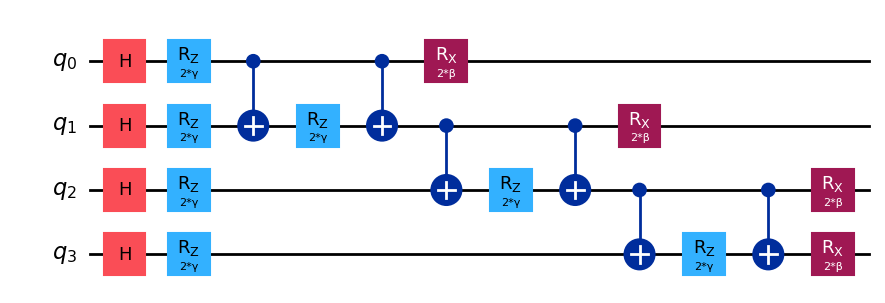

In [ ]:
# ============================================================
# QAOA Circuit Construction
# ============================================================

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.visualization import circuit_drawer


def create_qaoa_circuit_p1(n_qubits=4):

    """
    Create a single-layer (p=1) QAOA circuit

    Components:
    - Superposition initialization
    - Cost Hamiltonian
    - Mixer Hamiltonian
    """

    qc = QuantumCircuit(n_qubits)

    # QAOA trainable parameters
    gamma = Parameter('γ')

    beta = Parameter('β')

    # ========================================================
    # Step 1: Superposition Initialization
    # ========================================================

    # Create equal superposition of all routing states
    qc.h(range(n_qubits))

    # ========================================================
    # Step 2: Cost Hamiltonian
    # ========================================================

    # Single-qubit cost terms
    for i in range(n_qubits):

        qc.rz(2 * gamma, i)

    # Interaction cost terms
    for i in range(n_qubits - 1):

        qc.cx(i, i + 1)

        qc.rz(2 * gamma, i + 1)

        qc.cx(i, i + 1)

    # ========================================================
    # Step 3: Mixer Hamiltonian
    # ========================================================

    # Explore alternative routing configurations
    for i in range(n_qubits):

        qc.rx(2 * beta, i)

    return qc


# ============================================================
# Create and Display QAOA Circuit
# ============================================================

qc = create_qaoa_circuit_p1(4)

qc.draw('mpl')

QAOA — Quantum Mode Optimization
Path: 0 → 1 → 2 → 3 → 5 → 7 → 8 → 9
Bi-functional nodes: [1, 2, 5, 7]
Number of qubits: 4

QAOA Circuit:



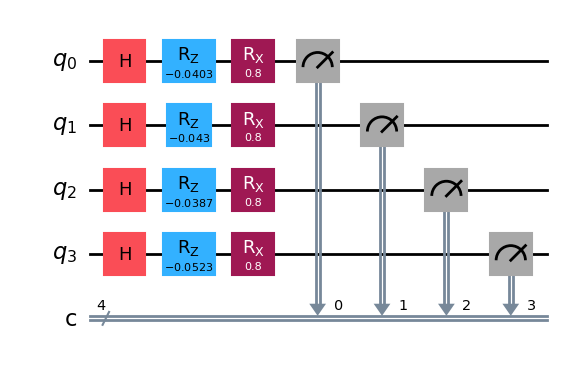


Measurement Counts: {'1101': 61, '0101': 66, '1001': 68, '1100': 64, '0000': 56, '0010': 51, '0100': 74, '1011': 80, '0011': 65, '0111': 58, '1110': 63, '1000': 73, '0110': 55, '0001': 59, '1111': 65, '1010': 66}
Best bitstring: 1011

Final Mode Assignment: ['T', 'H2H', 'T', 'T', 'T', 'T', 'T', 'T']


In [ ]:
# ============================================================
# QAOA-Based Quantum Routing Optimization
# ============================================================

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator

import numpy as np


# ============================================================
# Identify Bi-functional Decision Nodes
# ============================================================

def get_bi_nodes(G, path):

    bi_nodes = []

    bi_indices = []

    for i, node in enumerate(path):

        if G.nodes[node]['type'] == 'bi':

            next_node = (
                path[i + 1]
                if i + 1 < len(path)
                else None
            )

            if next_node is not None:

                bi_nodes.append(node)

                bi_indices.append(i)

    return bi_nodes, bi_indices


# ============================================================
# Compute QAOA Cost Coefficients
# ============================================================

def compute_cost_coeffs(G, path):

    c_T = []

    c_H = []

    cumulative_time = 0.0

    for i, node in enumerate(path):

        d = G.nodes[node]

        tau = d['tau']

        lam = d['lambda']

        W = 1.0 / lam

        # Memory decoherence factor
        decay = np.exp(
            -0.3 * cumulative_time / tau
        )

        # Teleportation routing cost
        c_T_i = -np.log(
            d['RT'] * decay
        )

        # H2H routing cost
        c_H_i = -np.log(
            d['RH'] * decay
        )

        c_T.append(c_T_i)

        c_H.append(c_H_i)

        cumulative_time += (
            d['PT'] + W
        )

    return np.array(c_T), np.array(c_H)


# ============================================================
# Build QAOA Circuit
# ============================================================

def build_qaoa_circuit(n, c_T, c_H):

    qc = QuantumCircuit(n, n)

    # Trainable QAOA parameters
    gamma = Parameter('γ')

    beta = Parameter('β')

    # ── Initialization ───────────────────────────────────

    # Create superposition of routing states
    qc.h(range(n))

    # ── Cost Hamiltonian ────────────────────────────────

    for i in range(n):

        # Cost difference between H2H and T
        cost_diff = c_H[i] - c_T[i]

        qc.rz(
            2 * gamma * cost_diff,
            i
        )

    # ── Mixer Hamiltonian ───────────────────────────────

    for i in range(n):

        qc.rx(
            2 * beta,
            i
        )

    # Measurements
    qc.measure(range(n), range(n))

    return qc


# ============================================================
# Execute QAOA Optimization
# ============================================================

def run_qaoa(G, path):

    bi_nodes, bi_indices = \
        get_bi_nodes(G, path)

    n = len(bi_indices)

    print("=" * 60)

    print("QAOA — Quantum Mode Optimization")

    print("=" * 60)

    print(f"Path: {' → '.join(map(str, path))}")

    print(f"Bi-functional nodes: {bi_nodes}")

    print(f"Number of qubits: {n}")

    # No optimization needed
    if n == 0:

        print("No decision nodes — all teleportation")

        return [], {}, []

    # ====================================================
    # Compute Routing Costs
    # ====================================================

    c_T_all, c_H_all = \
        compute_cost_coeffs(G, path)

    c_T = [
        c_T_all[i]
        for i in bi_indices
    ]

    c_H = [
        c_H_all[i]
        for i in bi_indices
    ]

    # ====================================================
    # Build and Configure QAOA Circuit
    # ====================================================

    qc = build_qaoa_circuit(
        n,
        c_T,
        c_H
    )

    qc = qc.assign_parameters({

        'γ': 0.8,

        'β': 0.4
    })

    print("\nQAOA Circuit:\n")

    display(qc.draw('mpl'))

    # ====================================================
    # Execute Quantum Simulation
    # ====================================================

    sim = AerSimulator()

    result = sim.run(
        qc,
        shots=1024
    ).result()

    counts = result.get_counts()

    # Most probable routing configuration
    best_state = max(
        counts,
        key=counts.get
    )

    print("\nMeasurement Counts:", counts)

    print("Best bitstring:", best_state)

    # ====================================================
    # Convert Bitstring to Routing Modes
    # ====================================================

    full_modes = []

    idx = 0

    for i, node in enumerate(path):

        d = G.nodes[node]

        next_node = (
            path[i + 1]
            if i + 1 < len(path)
            else None
        )

        current_is_mono = (
            d['type'] == 'mono'
        )

        next_is_mono = (
            G.nodes[next_node]['type'] == 'mono'
            if next_node
            else False
        )

        # Mono-functional nodes force teleportation
        if (
            current_is_mono
            or next_is_mono
            or i not in bi_indices
        ):

            full_modes.append('T')

        else:

            bit = int(best_state[idx])

            full_modes.append(
                'H2H'
                if bit == 1
                else 'T'
            )

            idx += 1

    print("\nFinal Mode Assignment:",
          full_modes)

    return best_state, counts, full_modes


# ============================================================
# Run QAOA Optimization
# ============================================================

best_state, counts, modes_qaoa = run_qaoa(
    G_gen,
    path_gen
)

OPTIMIZING QAOA PARAMETERS
Optimized γ, β: [1.4780016  1.00675451]

FINAL QAOA CIRCUIT:



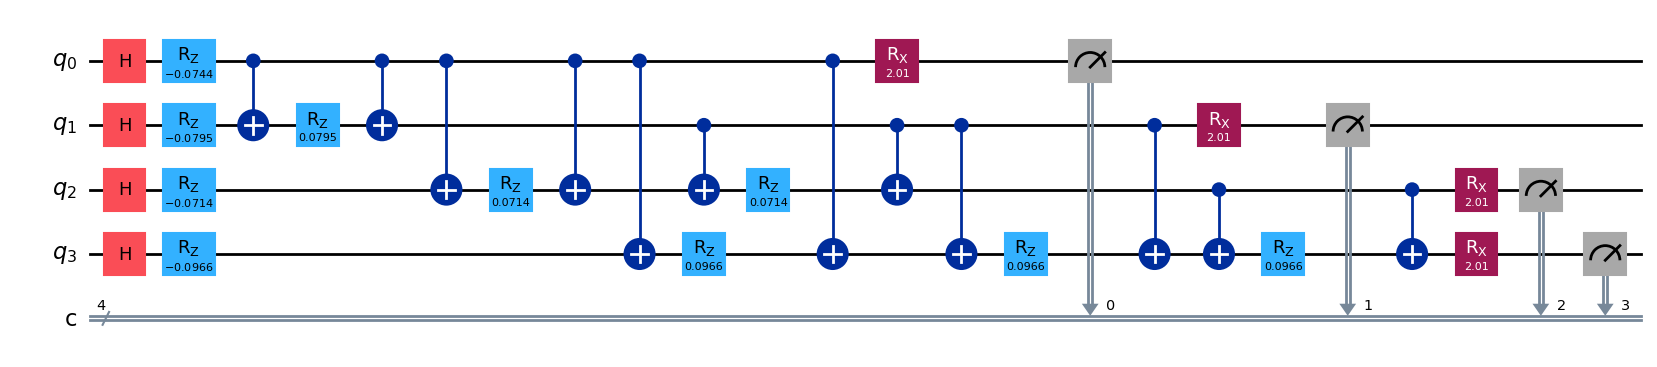


Final Counts: {'0010': 54, '1010': 78, '1101': 86, '0001': 48, '1111': 62, '0000': 26, '1011': 64, '0111': 74, '0011': 57, '0110': 68, '1000': 59, '1100': 80, '0100': 48, '1110': 72, '1001': 75, '0101': 73}
Best bitstring: 1101


In [ ]:
# ============================================================
# Time-Aware QAOA with Classical Parameter Optimization
# ============================================================

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator

import numpy as np

from scipy.optimize import minimize


# ============================================================
# Identify Bi-functional Decision Nodes
# ============================================================

def get_bi_nodes(G, path):

    bi_nodes = []

    bi_indices = []

    for i, node in enumerate(path):

        if G.nodes[node]['type'] == 'bi':

            next_node = (
                path[i + 1]
                if i + 1 < len(path)
                else None
            )

            if next_node is not None:

                bi_nodes.append(node)

                bi_indices.append(i)

    return bi_nodes, bi_indices


# ============================================================
# Evaluate Routing Cost for a Bitstring
# ============================================================

def evaluate_bitstring(G,
                       path,
                       bitstring,
                       bi_indices):

    Rse = 1.0

    cumulative_time = 0.0

    idx = 0

    for i, node in enumerate(path):

        d = G.nodes[node]

        tau = d['tau']

        lam = d['lambda']

        W = 1.0 / lam

        next_node = (
            path[i + 1]
            if i + 1 < len(path)
            else None
        )

        current_is_mono = (
            d['type'] == 'mono'
        )

        next_is_mono = (
            G.nodes[next_node]['type'] == 'mono'
            if next_node
            else False
        )

        # Forced teleportation
        if (
            current_is_mono
            or next_is_mono
            or i not in bi_indices
        ):

            mode = 'T'

        else:

            mode = (
                'H2H'
                if bitstring[idx] == 1
                else 'T'
            )

            idx += 1

        # Memory decoherence
        decay = np.exp(
            -0.3 * cumulative_time / tau
        )

        # Reliability selection
        if mode == 'T':

            R_used = d['RT'] * decay

            T_used = d['PT'] + W

        else:

            R_used = d['RH'] * decay

            T_used = d['PH']

        Rse *= R_used

        cumulative_time += T_used

    # Minimize routing cost
    return -np.log(Rse + 1e-12)


# ============================================================
# Compute Time-Aware QAOA Cost Coefficients
# ============================================================

def compute_time_aware_coeffs(G,
                              path,
                              bi_indices):

    c_T_all = []

    c_H_all = []

    cumulative_time = 0.0

    for i, node in enumerate(path):

        d = G.nodes[node]

        tau = d['tau']

        lam = d['lambda']

        W = 1.0 / lam

        # Decoherence factor
        decay = np.exp(
            -0.3 * cumulative_time / tau
        )

        c_T_all.append(
            -np.log(d['RT'] * decay)
        )

        c_H_all.append(
            -np.log(d['RH'] * decay)
        )

        cumulative_time += (
            d['PT'] + W
        )

    c_T = [
        c_T_all[i]
        for i in bi_indices
    ]

    c_H = [
        c_H_all[i]
        for i in bi_indices
    ]

    n = len(c_T)

    # Interaction matrix
    J = np.zeros((n, n))

    for i in range(n):

        for j in range(i + 1, n):

            J[i][j] = abs(
                c_H[j] - c_T[j]
            )

    return (
        np.array(c_T),
        np.array(c_H),
        J
    )


# ============================================================
# Build Time-Aware QAOA Circuit
# ============================================================

def build_time_aware_qaoa(n,
                          c_T,
                          c_H,
                          J):

    qc = QuantumCircuit(n, n)

    # Trainable QAOA parameters
    gamma = Parameter('γ')

    beta = Parameter('β')

    # ── Initialization ───────────────────────────────────

    # Create superposition of routing states
    qc.h(range(n))

    # ── Cost Hamiltonian ────────────────────────────────

    # Local cost terms
    for i in range(n):

        cost_diff = c_H[i] - c_T[i]

        qc.rz(
            2 * gamma * cost_diff,
            i
        )

    # Interaction terms
    for i in range(n):

        for j in range(i + 1, n):

            if J[i][j] != 0:

                qc.cx(i, j)

                qc.rz(
                    2 * gamma * J[i][j],
                    j
                )

                qc.cx(i, j)

    # ── Mixer Hamiltonian ───────────────────────────────

    for i in range(n):

        qc.rx(
            2 * beta,
            i
        )

    # Measurements
    qc.measure(range(n), range(n))

    return qc


# ============================================================
# QAOA Objective Function
# ============================================================

def qaoa_objective(params,
                   G,
                   path,
                   bi_indices):

    gamma, beta = params

    c_T, c_H, J = compute_time_aware_coeffs(
        G,
        path,
        bi_indices
    )

    n = len(c_T)

    qc = build_time_aware_qaoa(
        n,
        c_T,
        c_H,
        J
    )

    qc = qc.assign_parameters({

        'γ': gamma,

        'β': beta
    })

    # Quantum simulation
    sim = AerSimulator()

    result = sim.run(
        qc,
        shots=512
    ).result()

    counts = result.get_counts()

    cost = 0

    # Expected routing cost
    for bitstring, count in counts.items():

        bits = [int(b) for b in bitstring]

        c = evaluate_bitstring(
            G,
            path,
            bits,
            bi_indices
        )

        cost += c * count

    return cost / 512


# ============================================================
# Classical Optimization of QAOA Parameters
# ============================================================

def optimize_qaoa(G, path):

    bi_nodes, bi_indices = \
        get_bi_nodes(G, path)

    print("=" * 60)

    print("OPTIMIZING QAOA PARAMETERS")

    print("=" * 60)

    # COBYLA classical optimizer
    res = minimize(

        qaoa_objective,

        x0=[0.5, 0.5],

        args=(G, path, bi_indices),

        method='COBYLA'
    )

    print("Optimized γ, β:", res.x)

    return res.x


# ============================================================
# Final QAOA Execution
# ============================================================

def run_final_qaoa(G, path):

    bi_nodes, bi_indices = \
        get_bi_nodes(G, path)

    n = len(bi_indices)

    # Optimize parameters
    gamma, beta = optimize_qaoa(
        G,
        path
    )

    # Compute QAOA coefficients
    c_T, c_H, J = \
        compute_time_aware_coeffs(
            G,
            path,
            bi_indices
        )

    # Build final circuit
    qc = build_time_aware_qaoa(
        n,
        c_T,
        c_H,
        J
    )

    qc = qc.assign_parameters({

        'γ': gamma,

        'β': beta
    })

    print("\nFINAL QAOA CIRCUIT:\n")

    display(qc.draw('mpl'))

    # Final execution
    sim = AerSimulator()

    result = sim.run(
        qc,
        shots=1024
    ).result()

    counts = result.get_counts()

    # Best routing configuration
    best_state = max(
        counts,
        key=counts.get
    )

    print("\nFinal Counts:", counts)

    print("Best bitstring:", best_state)

    return best_state, counts


# ============================================================
# Run Final QAOA Optimization
# ============================================================

best_state, counts = run_final_qaoa(
    G_gen,
    path_gen
)

# Simulator vs IBM Hardware Comparison

In [ ]:
!pip install qiskit qiskit-ibm-runtime qiskit-aer -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.0/218.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 9.9 MB/s eta 0:00:00


In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="YOUR_API_KEY",
    overwrite=True
)

In [ ]:
service = QiskitRuntimeService()

qiskit_runtime_service.__init__:WARNING:2026-05-19 19:44:06,143: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [ ]:
backends = service.backends(
    simulator=False,
    operational=True
)

for b in backends:
    print(b.name)

qiskit_runtime_service.backends:WARNING:2026-05-19 19:44:07,911: Loading instance: open-instance, plan: open


ibm_kingston
ibm_marrakesh
ibm_fez


In [ ]:
backend = service.backend("ibm_kingston")

print(backend)

qiskit_runtime_service.backends:WARNING:2026-05-19 19:44:11,641: Using instance: open-instance, plan: open


<IBMBackend('ibm_kingston')>


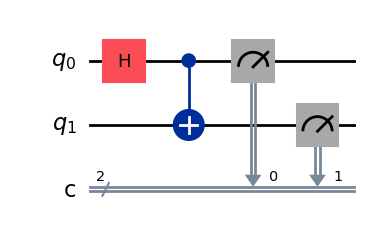

In [ ]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2, 2)

# Create Bell state
qc.h(0)
qc.cx(0, 1)

# Measure qubits
qc.measure([0,1], [0,1])

# try:
#   display(qc.draw("mpl"))
# except:
qc.draw("mpl")

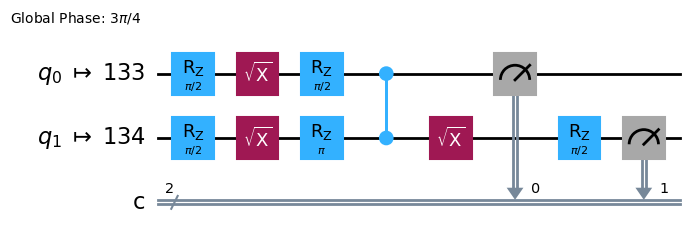

In [ ]:
from qiskit import transpile

# Convert circuit to IBM hardware native gates
qc_transpiled = transpile(
    qc,
    backend=backend,
    optimization_level=3
)
# print(qc_transpiled.draw())
qc_transpiled.draw("mpl")

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)

job = sampler.run([qc_transpiled], shots=1024)

print("Job ID:", job.job_id())

Job ID: d86brd5g7okc73ektt3g


In [ ]:
result = job.result()

In [ ]:
counts = result[0].data.c.get_counts()

print(counts)

{'00': 531, '11': 468, '10': 18, '01': 7}


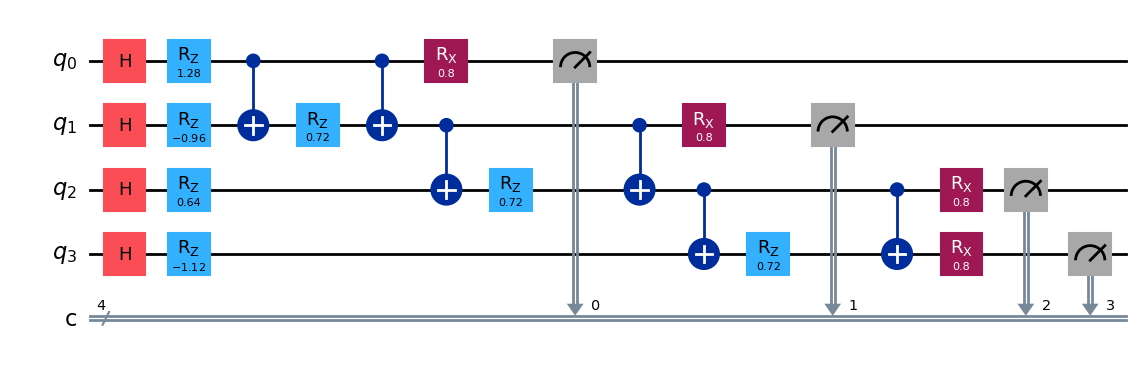

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
import numpy as np

# ─────────────────────────────────────────────────────────
# 4-Qubit QAOA with Interaction Terms
# ─────────────────────────────────────────────────────────

n = 4

qc_qaoa = QuantumCircuit(n, n)

gamma = Parameter("γ")
beta  = Parameter("β")

# ─────────────────────────────────────────────────────────
# Step 1: Superposition
# ─────────────────────────────────────────────────────────

qc_qaoa.h(range(n))

# ─────────────────────────────────────────────────────────
# Step 2: Single-Qubit Cost Terms
# ─────────────────────────────────────────────────────────

routing_costs = [0.8, -0.6, 0.4, -0.7]

for i in range(n):
    qc_qaoa.rz(2 * gamma * routing_costs[i], i)

# ─────────────────────────────────────────────────────────
# Step 3: Pairwise Interaction Terms
# CX-RZ-CX blocks
# ─────────────────────────────────────────────────────────

interaction_strength = 0.45

for i in range(n - 1):

    qc_qaoa.cx(i, i+1)

    qc_qaoa.rz(
        2 * gamma * interaction_strength,
        i+1
    )

    qc_qaoa.cx(i, i+1)

# ─────────────────────────────────────────────────────────
# Step 4: Mixer Hamiltonian
# ─────────────────────────────────────────────────────────

for i in range(n):
    qc_qaoa.rx(2 * beta, i)

# ─────────────────────────────────────────────────────────
# Measurements
# ─────────────────────────────────────────────────────────

qc_qaoa.measure(range(n), range(n))

# ─────────────────────────────────────────────────────────
# Assign Parameters
# ─────────────────────────────────────────────────────────

qc_qaoa = qc_qaoa.assign_parameters({
    gamma: 0.8,
    beta: 0.4
})

# print(qc_qaoa.draw())
qc_qaoa.draw("mpl")

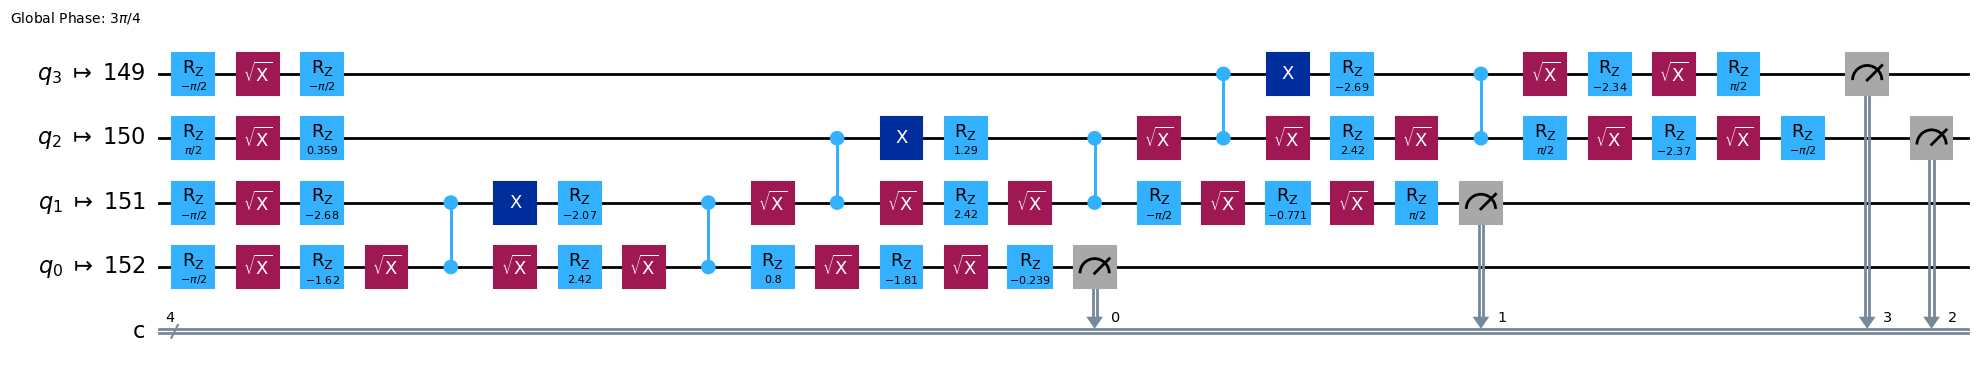

In [ ]:
from qiskit import transpile

qc_transpiled = transpile(
    qc_qaoa,
    backend=backend,
    optimization_level=3
)

# print(qc_transpiled.draw())
# qc_transpiled.draw("mpl")
qc_transpiled.draw(
    "mpl",
    fold=-1
)

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)

job = sampler.run([qc_transpiled], shots=1024)

print("Job ID:", job.job_id())

Job ID: d86bt2is46sc73f6q010


In [ ]:
result = job.result()

In [ ]:
counts = result[0].data.c.get_counts()

print(counts)

{'0010': 106, '1000': 167, '0000': 73, '1111': 63, '1110': 236, '1010': 144, '1011': 72, '0001': 11, '0011': 40, '1101': 34, '1001': 26, '0101': 5, '0110': 20, '0100': 13, '1100': 13, '0111': 1}


In [ ]:
best_state = max(counts, key=counts.get)

print("Best bitstring:", best_state)

Best bitstring: 1110


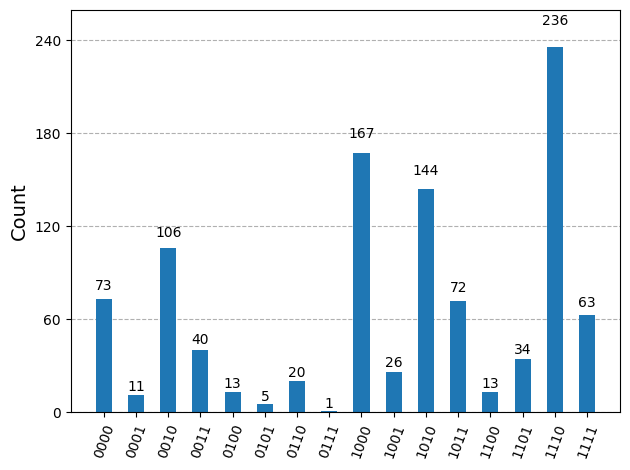

In [ ]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)

In [ ]:
from qiskit_aer import AerSimulator

# Ideal simulator
sim = AerSimulator()

# Run SAME transpiled circuit
job_sim = sim.run(qc_transpiled, shots=1024)

result_sim = job_sim.result()

counts_sim = result_sim.get_counts()

print(counts_sim)

{'0001': 3, '1101': 31, '1010': 129, '0101': 6, '1001': 19, '1100': 13, '1011': 66, '0011': 52, '0111': 1, '1110': 246, '0000': 73, '0010': 88, '1000': 189, '0110': 12, '1111': 78, '0100': 18}


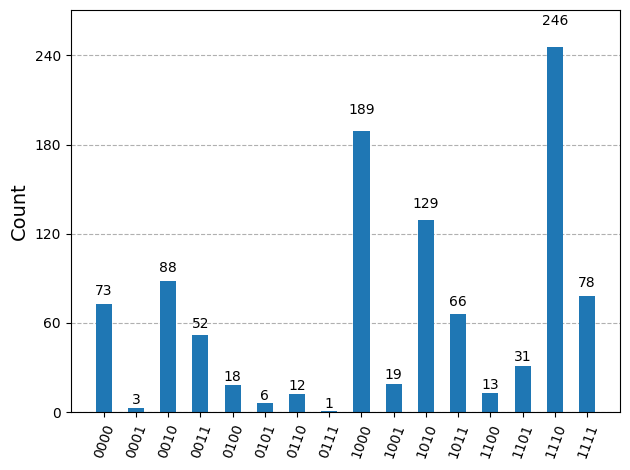

In [ ]:
from qiskit.visualization import plot_histogram

plot_histogram(counts_sim)

In [ ]:
best_sim = max(counts_sim, key=counts_sim.get)
best_hw  = max(counts, key=counts.get)

print("Simulator Best State :", best_sim)
print("Hardware  Best State :", best_hw)

Simulator Best State : 1110
Hardware  Best State : 1110


In [ ]:
sim_prob = counts_sim[best_sim] / 1024
hw_prob  = counts[best_hw] / 1024

print(f"Simulator Dominant Probability : {sim_prob:.4f}")
print(f"Hardware  Dominant Probability : {hw_prob:.4f}")

Simulator Dominant Probability : 0.2402
Hardware  Dominant Probability : 0.2305


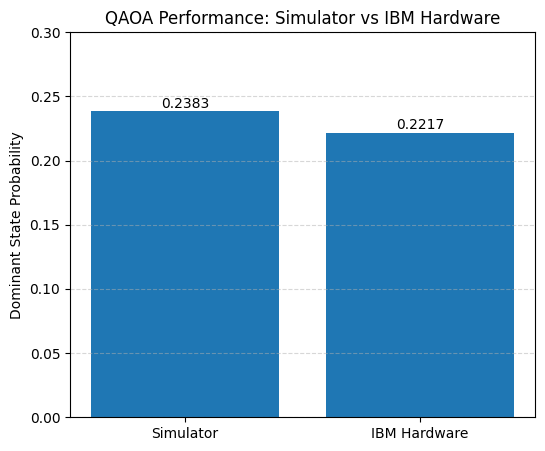

In [ ]:
import matplotlib.pyplot as plt

labels = ["Simulator", "IBM Hardware"]
values = [0.2383, 0.2217]

plt.figure(figsize=(6,5))

bars = plt.bar(labels, values)

plt.ylabel("Dominant State Probability")
plt.title("QAOA Performance: Simulator vs IBM Hardware")

for bar in bars:
    y = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.003,
        f"{y:.4f}",
        ha='center'
    )

plt.ylim(0, 0.30)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Experimental Results and Performance Analysis

Running experiments for bifunctional probability = 0.2
Running experiments for bifunctional probability = 0.4
Running experiments for bifunctional probability = 0.6
Running experiments for bifunctional probability = 0.8
Running experiments for bifunctional probability = 1.0


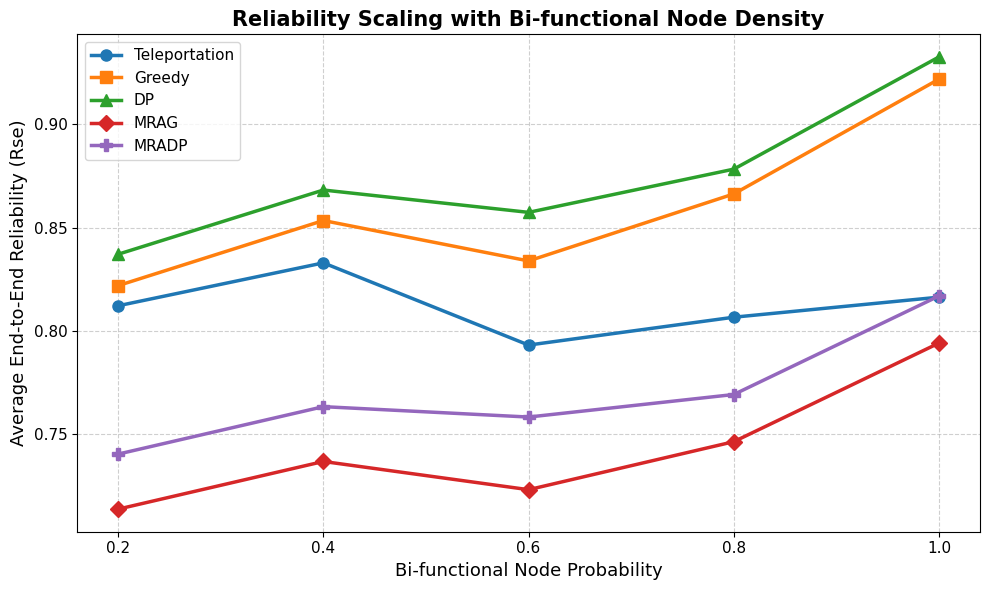


AVERAGED RESULTS
Prob      Teleportation     Greedy            DP                MRAG              MRADP             
---------------------------------------------------------------------------
0.2       0.812182          0.821952          0.837142          0.713724          0.740368          
0.4       0.832952          0.853456          0.868225          0.736789          0.763331          
0.6       0.793154          0.833890          0.857407          0.723131          0.758302          
0.8       0.806640          0.866327          0.878331          0.746372          0.769216          
1.0       0.816346          0.921902          0.932659          0.794121          0.816910          


In [ ]:
# ═══════════════════════════════════════════════════════════
# EXPERIMENT 1 — RELIABILITY SCALING
# % Bifunctional Nodes vs Reliability
# ═══════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import numpy as np

# ─── Experiment settings ─────────────────────────────────
bifunctional_probs = [0.2, 0.4, 0.6, 0.8, 1.0]

NUM_RUNS = 10
T_constraint = 20.0

results = {
    'Teleportation': [],
    'Greedy': [],
    'DP': [],
    'MRAG': [],
    'MRADP': []
}

# ─── Main experiment ─────────────────────────────────────
for p in bifunctional_probs:

    print("="*70)
    print(f"Running experiments for bifunctional probability = {p}")
    print("="*70)

    temp_results = {
        'Teleportation': [],
        'Greedy': [],
        'DP': [],
        'MRAG': [],
        'MRADP': []
    }

    # ─── Multiple runs for averaging ─────────────────────
    for run in range(NUM_RUNS):

        # Generate random graph
        G_exp, path_exp = create_general_graph(
            num_nodes=10,
            extra_edges=3,
            bifunctional_prob=p
        )

        # ─── Teleportation ───────────────────────────────
        Rse_t, _, _ = teleportation_only(G_exp, path_exp)

        # ─── Greedy ──────────────────────────────────────
        Rse_g, _, _ = greedy_base(G_exp, path_exp)

        # ─── DP ──────────────────────────────────────────
        Rse_dp, _, _ = dp_base(
            G_exp,
            path_exp,
            T_constraint
        )

        # ─── MRAG ────────────────────────────────────────
        Rse_mrag, _, _, _ = mrag(
            G_exp,
            path_exp
        )

        # ─── MRADP ───────────────────────────────────────
        Rse_mradp, _, _ = mradp(
            G_exp,
            path_exp,
            T_constraint
        )

        # Store temporary results
        temp_results['Teleportation'].append(Rse_t)
        temp_results['Greedy'].append(Rse_g)
        temp_results['DP'].append(Rse_dp)
        temp_results['MRAG'].append(Rse_mrag)
        temp_results['MRADP'].append(Rse_mradp)

    # ─── Average results ────────────────────────────────
    for algo in results.keys():
        avg_val = np.mean(temp_results[algo])
        results[algo].append(avg_val)

# ─── Publication-quality plot ───────────────────────────
plt.figure(figsize=(10,6))

markers = {
    'Teleportation': 'o',
    'Greedy': 's',
    'DP': '^',
    'MRAG': 'D',
    'MRADP': 'P'
}

for algo, values in results.items():

    plt.plot(
        bifunctional_probs,
        values,
        marker=markers[algo],
        linewidth=2.5,
        markersize=8,
        label=algo
    )

# ─── Formatting ──────────────────────────────────────────
plt.xlabel('Bi-functional Node Probability', fontsize=13)
plt.ylabel('Average End-to-End Reliability (Rse)', fontsize=13)

plt.title(
    'Reliability Scaling with Bi-functional Node Density',
    fontsize=15,
    fontweight='bold'
)

plt.xticks(bifunctional_probs, fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(fontsize=11)

plt.tight_layout()

plt.show()

# ─── Print numerical table ──────────────────────────────
print("\nAVERAGED RESULTS")
print("="*75)

header = f"{'Prob':<10}"
for algo in results.keys():
    header += f"{algo:<18}"

print(header)
print("-"*75)

for i, p in enumerate(bifunctional_probs):

    row = f"{p:<10}"

    for algo in results.keys():
        row += f"{results[algo][i]:<18.6f}"

    print(row)

print("="*75)
# plt.savefig("network_scalability.png", dpi=600, bbox_inches='tight')

Running experiments for τ = 5
Running experiments for τ = 10
Running experiments for τ = 20
Running experiments for τ = 40
Running experiments for τ = 80


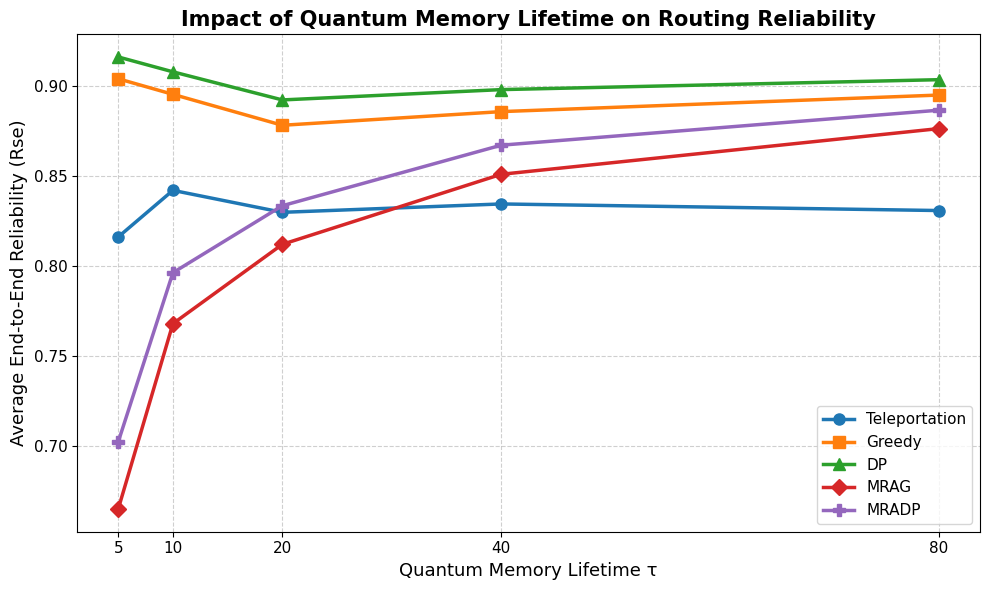


AVERAGED RESULTS
τ         Teleportation     Greedy            DP                MRAG              MRADP             
---------------------------------------------------------------------------
5         0.816072          0.904099          0.916226          0.664704          0.702039          
10        0.842013          0.895419          0.907947          0.767851          0.796201          
20        0.829791          0.878216          0.892311          0.811993          0.833471          
40        0.834454          0.885813          0.898053          0.850950          0.867137          
80        0.830786          0.895023          0.903580          0.876376          0.886616          


<Figure size 640x480 with 0 Axes>

In [ ]:
# ═══════════════════════════════════════════════════════════
# EXPERIMENT 2 — MEMORY LIFETIME (τ) EXPERIMENT
# τ vs End-to-End Reliability
# ═══════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import numpy as np

# ─── τ values ────────────────────────────────────────────
tau_values = [5, 10, 20, 40, 80]

NUM_RUNS = 10
T_constraint = 20.0

results_tau = {
    'Teleportation': [],
    'Greedy': [],
    'DP': [],
    'MRAG': [],
    'MRADP': []
}

# ─── Main experiment ─────────────────────────────────────
for tau_fixed in tau_values:

    print("="*70)
    print(f"Running experiments for τ = {tau_fixed}")
    print("="*70)

    temp_results = {
        'Teleportation': [],
        'Greedy': [],
        'DP': [],
        'MRAG': [],
        'MRADP': []
    }

    for run in range(NUM_RUNS):

        # ─── Generate graph ───────────────────────────────
        G_exp, path_exp = create_general_graph(
            num_nodes=10,
            extra_edges=3,
            bifunctional_prob=0.8
        )

        # ─── FORCE SAME τ FOR ALL NODES ──────────────────
        for node in G_exp.nodes():

            G_exp.nodes[node]['tau'] = tau_fixed

        # ─── Teleportation ───────────────────────────────
        Rse_t, _, _ = teleportation_only(G_exp, path_exp)

        # ─── Greedy ──────────────────────────────────────
        Rse_g, _, _ = greedy_base(G_exp, path_exp)

        # ─── DP ──────────────────────────────────────────
        Rse_dp, _, _ = dp_base(
            G_exp,
            path_exp,
            T_constraint
        )

        # ─── MRAG ────────────────────────────────────────
        Rse_mrag, _, _, _ = mrag(
            G_exp,
            path_exp
        )

        # ─── MRADP ───────────────────────────────────────
        Rse_mradp, _, _ = mradp(
            G_exp,
            path_exp,
            T_constraint
        )

        # Store
        temp_results['Teleportation'].append(Rse_t)
        temp_results['Greedy'].append(Rse_g)
        temp_results['DP'].append(Rse_dp)
        temp_results['MRAG'].append(Rse_mrag)
        temp_results['MRADP'].append(Rse_mradp)

    # ─── Average ─────────────────────────────────────────
    for algo in results_tau.keys():
        avg_val = np.mean(temp_results[algo])
        results_tau[algo].append(avg_val)

# ─── Plot ────────────────────────────────────────────────
plt.figure(figsize=(10,6))

markers = {
    'Teleportation': 'o',
    'Greedy': 's',
    'DP': '^',
    'MRAG': 'D',
    'MRADP': 'P'
}

for algo, values in results_tau.items():

    plt.plot(
        tau_values,
        values,
        marker=markers[algo],
        linewidth=2.5,
        markersize=8,
        label=algo
    )

# ─── Formatting ──────────────────────────────────────────
plt.xlabel('Quantum Memory Lifetime τ', fontsize=13)

plt.ylabel(
    'Average End-to-End Reliability (Rse)',
    fontsize=13
)

plt.title(
    'Impact of Quantum Memory Lifetime on Routing Reliability',
    fontsize=15,
    fontweight='bold'
)

plt.xticks(tau_values, fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(fontsize=11)

plt.tight_layout()

plt.show()
plt.savefig("memory_lifetime.png", dpi=600, bbox_inches='tight')

# ─── Numerical table ─────────────────────────────────────
print("\nAVERAGED RESULTS")
print("="*75)

header = f"{'τ':<10}"
for algo in results_tau.keys():
    header += f"{algo:<18}"

print(header)
print("-"*75)

for i, tau in enumerate(tau_values):

    row = f"{tau:<10}"

    for algo in results_tau.keys():
        row += f"{results_tau[algo][i]:<18.6f}"

    print(row)

print("="*75)

Running experiments for λ = 2
Running experiments for λ = 5
Running experiments for λ = 10
Running experiments for λ = 20
Running experiments for λ = 40


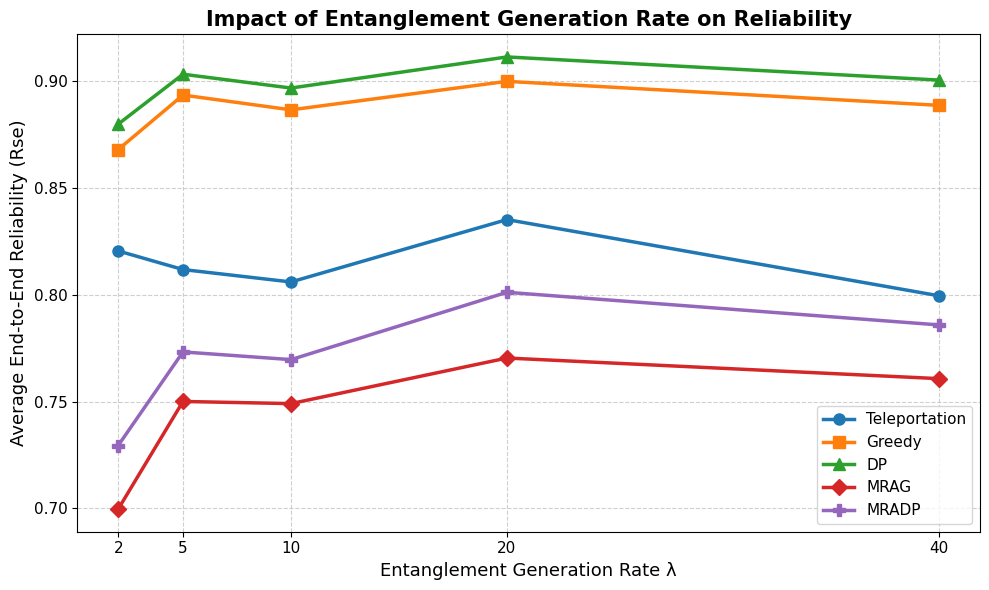


AVERAGED RESULTS
λ         Teleportation     Greedy            DP                MRAG              MRADP             
---------------------------------------------------------------------------
2         0.820477          0.867918          0.879807          0.699664          0.729424          
5         0.811769          0.893415          0.903169          0.750043          0.773224          
10        0.805960          0.886498          0.896706          0.749033          0.769618          
20        0.835148          0.899830          0.911255          0.770366          0.801126          
40        0.799490          0.888602          0.900426          0.760716          0.785857          


<Figure size 640x480 with 0 Axes>

In [ ]:
# ═══════════════════════════════════════════════════════════
# EXPERIMENT 3 — ENTANGLEMENT GENERATION RATE (λ)
# λ vs End-to-End Reliability
# ═══════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import numpy as np

# ─── λ values ────────────────────────────────────────────
lambda_values = [2, 5, 10, 20, 40]

NUM_RUNS = 10
T_constraint = 20.0

results_lambda = {
    'Teleportation': [],
    'Greedy': [],
    'DP': [],
    'MRAG': [],
    'MRADP': []
}

# ─── Main experiment ─────────────────────────────────────
for lambda_fixed in lambda_values:

    print("="*70)
    print(f"Running experiments for λ = {lambda_fixed}")
    print("="*70)

    temp_results = {
        'Teleportation': [],
        'Greedy': [],
        'DP': [],
        'MRAG': [],
        'MRADP': []
    }

    for run in range(NUM_RUNS):

        # ─── Generate graph ───────────────────────────────
        G_exp, path_exp = create_general_graph(
            num_nodes=10,
            extra_edges=3,
            bifunctional_prob=0.8
        )

        # ─── FORCE SAME λ FOR ALL NODES ──────────────────
        for node in G_exp.nodes():

            G_exp.nodes[node]['lambda'] = lambda_fixed
            G_exp.nodes[node]['W'] = 1.0 / lambda_fixed

        # ─── Teleportation ───────────────────────────────
        Rse_t, _, _ = teleportation_only(G_exp, path_exp)

        # ─── Greedy ──────────────────────────────────────
        Rse_g, _, _ = greedy_base(G_exp, path_exp)

        # ─── DP ──────────────────────────────────────────
        Rse_dp, _, _ = dp_base(
            G_exp,
            path_exp,
            T_constraint
        )

        # ─── MRAG ────────────────────────────────────────
        Rse_mrag, _, _, _ = mrag(
            G_exp,
            path_exp
        )

        # ─── MRADP ───────────────────────────────────────
        Rse_mradp, _, _ = mradp(
            G_exp,
            path_exp,
            T_constraint
        )

        # Store
        temp_results['Teleportation'].append(Rse_t)
        temp_results['Greedy'].append(Rse_g)
        temp_results['DP'].append(Rse_dp)
        temp_results['MRAG'].append(Rse_mrag)
        temp_results['MRADP'].append(Rse_mradp)

    # ─── Average ─────────────────────────────────────────
    for algo in results_lambda.keys():
        avg_val = np.mean(temp_results[algo])
        results_lambda[algo].append(avg_val)

# ─── Plot ────────────────────────────────────────────────
plt.figure(figsize=(10,6))

markers = {
    'Teleportation': 'o',
    'Greedy': 's',
    'DP': '^',
    'MRAG': 'D',
    'MRADP': 'P'
}

for algo, values in results_lambda.items():

    plt.plot(
        lambda_values,
        values,
        marker=markers[algo],
        linewidth=2.5,
        markersize=8,
        label=algo
    )

# ─── Formatting ──────────────────────────────────────────
plt.xlabel('Entanglement Generation Rate λ', fontsize=13)

plt.ylabel(
    'Average End-to-End Reliability (Rse)',
    fontsize=13
)

plt.title(
    'Impact of Entanglement Generation Rate on Reliability',
    fontsize=15,
    fontweight='bold'
)

plt.xticks(lambda_values, fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(fontsize=11)

plt.tight_layout()

plt.show()
plt.savefig("entanglement_rate.png", dpi=600, bbox_inches='tight')

# ─── Numerical table ─────────────────────────────────────
print("\nAVERAGED RESULTS")
print("="*75)

header = f"{'λ':<10}"
for algo in results_lambda.keys():
    header += f"{algo:<18}"

print(header)
print("-"*75)

for i, lam in enumerate(lambda_values):

    row = f"{lam:<10}"

    for algo in results_lambda.keys():
        row += f"{results_lambda[algo][i]:<18.6f}"

    print(row)

print("="*75)

Running experiments for network size = 5
Running experiments for network size = 8
Running experiments for network size = 10
Running experiments for network size = 12
Running experiments for network size = 15


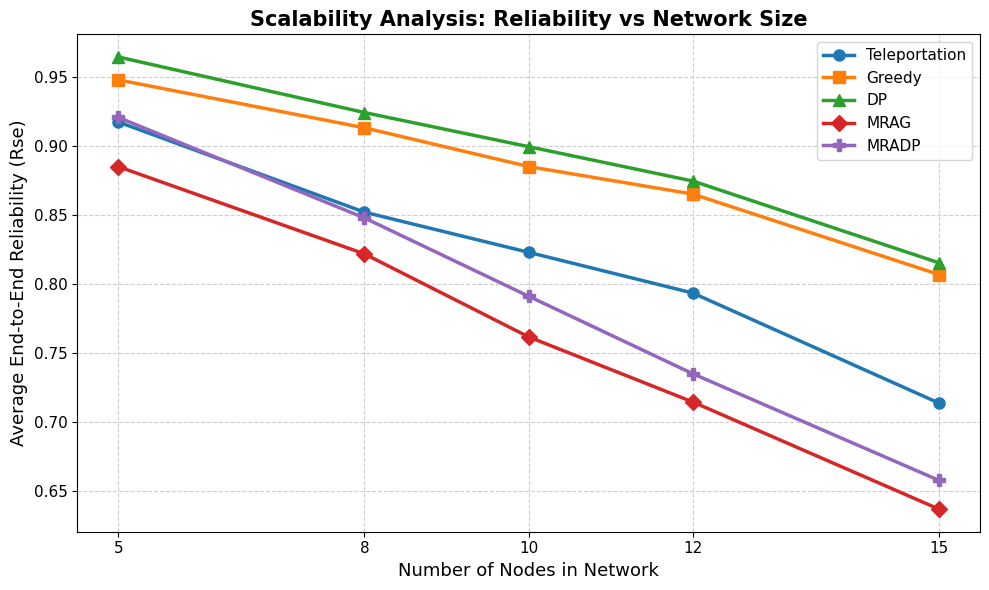


AVERAGED RESULTS
Nodes     Teleportation     Greedy            DP                MRAG              MRADP             
---------------------------------------------------------------------------
5         0.917730          0.948245          0.964848          0.885333          0.921023          
8         0.852315          0.913496          0.924544          0.822067          0.848129          
10        0.823209          0.885387          0.899805          0.761901          0.791381          
12        0.793714          0.865447          0.874889          0.714716          0.735198          
15        0.713888          0.807074          0.815612          0.637028          0.657887          


<Figure size 640x480 with 0 Axes>

In [ ]:
# ═══════════════════════════════════════════════════════════
# EXPERIMENT 4 — SCALABILITY (PATH LENGTH)
# Path Length vs Reliability
# ═══════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import numpy as np

# ─── Network sizes ───────────────────────────────────────
node_sizes = [5, 8, 10, 12, 15]

NUM_RUNS = 10
T_constraint = 20.0

results_scale = {
    'Teleportation': [],
    'Greedy': [],
    'DP': [],
    'MRAG': [],
    'MRADP': []
}

# ─── Main experiment ─────────────────────────────────────
for n_nodes in node_sizes:

    print("="*70)
    print(f"Running experiments for network size = {n_nodes}")
    print("="*70)

    temp_results = {
        'Teleportation': [],
        'Greedy': [],
        'DP': [],
        'MRAG': [],
        'MRADP': []
    }

    for run in range(NUM_RUNS):

        # ─── Generate graph ───────────────────────────────
        G_exp, path_exp = create_general_graph(
            num_nodes=n_nodes,
            extra_edges=3,
            bifunctional_prob=0.8
        )

        # ─── Teleportation ───────────────────────────────
        Rse_t, _, _ = teleportation_only(G_exp, path_exp)

        # ─── Greedy ──────────────────────────────────────
        Rse_g, _, _ = greedy_base(G_exp, path_exp)

        # ─── DP ──────────────────────────────────────────
        Rse_dp, _, _ = dp_base(
            G_exp,
            path_exp,
            T_constraint
        )

        # ─── MRAG ────────────────────────────────────────
        Rse_mrag, _, _, _ = mrag(
            G_exp,
            path_exp
        )

        # ─── MRADP ───────────────────────────────────────
        Rse_mradp, _, _ = mradp(
            G_exp,
            path_exp,
            T_constraint
        )

        # Store
        temp_results['Teleportation'].append(Rse_t)
        temp_results['Greedy'].append(Rse_g)
        temp_results['DP'].append(Rse_dp)
        temp_results['MRAG'].append(Rse_mrag)
        temp_results['MRADP'].append(Rse_mradp)

    # ─── Average results ─────────────────────────────────
    for algo in results_scale.keys():
        avg_val = np.mean(temp_results[algo])
        results_scale[algo].append(avg_val)

# ─── Plot ────────────────────────────────────────────────
plt.figure(figsize=(10,6))

markers = {
    'Teleportation': 'o',
    'Greedy': 's',
    'DP': '^',
    'MRAG': 'D',
    'MRADP': 'P'
}

for algo, values in results_scale.items():

    plt.plot(
        node_sizes,
        values,
        marker=markers[algo],
        linewidth=2.5,
        markersize=8,
        label=algo
    )

# ─── Formatting ──────────────────────────────────────────
plt.xlabel('Number of Nodes in Network', fontsize=13)

plt.ylabel(
    'Average End-to-End Reliability (Rse)',
    fontsize=13
)

plt.title(
    'Scalability Analysis: Reliability vs Network Size',
    fontsize=15,
    fontweight='bold'
)

plt.xticks(node_sizes, fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(fontsize=11)

plt.tight_layout()

plt.show()
plt.savefig("network_scalability.png", dpi=600, bbox_inches='tight')

# ─── Numerical table ─────────────────────────────────────
print("\nAVERAGED RESULTS")
print("="*75)

header = f"{'Nodes':<10}"
for algo in results_scale.keys():
    header += f"{algo:<18}"

print(header)
print("-"*75)

for i, n in enumerate(node_sizes):

    row = f"{n:<10}"

    for algo in results_scale.keys():
        row += f"{results_scale[algo][i]:<18.6f}"

    print(row)

print("="*75)

Running for 2 decision qubits
Search space: 4
Classical time: 0.000034 sec
QAOA time: 0.016195 sec
Running for 4 decision qubits
Search space: 16
Classical time: 0.000055 sec
QAOA time: 0.007204 sec
Running for 6 decision qubits
Search space: 64
Classical time: 0.000217 sec
QAOA time: 0.014719 sec
Running for 8 decision qubits
Search space: 256
Classical time: 0.000753 sec
QAOA time: 0.023511 sec
Running for 10 decision qubits
Search space: 1024
Classical time: 0.012168 sec
QAOA time: 0.024863 sec
Running for 15 decision qubits
Search space: 32768
Classical time: 0.390485 sec
QAOA time: 0.207206 sec
Running for 20 decision qubits
Search space: 1048576
Classical time: 4.990690 sec
QAOA time: 0.272770 sec


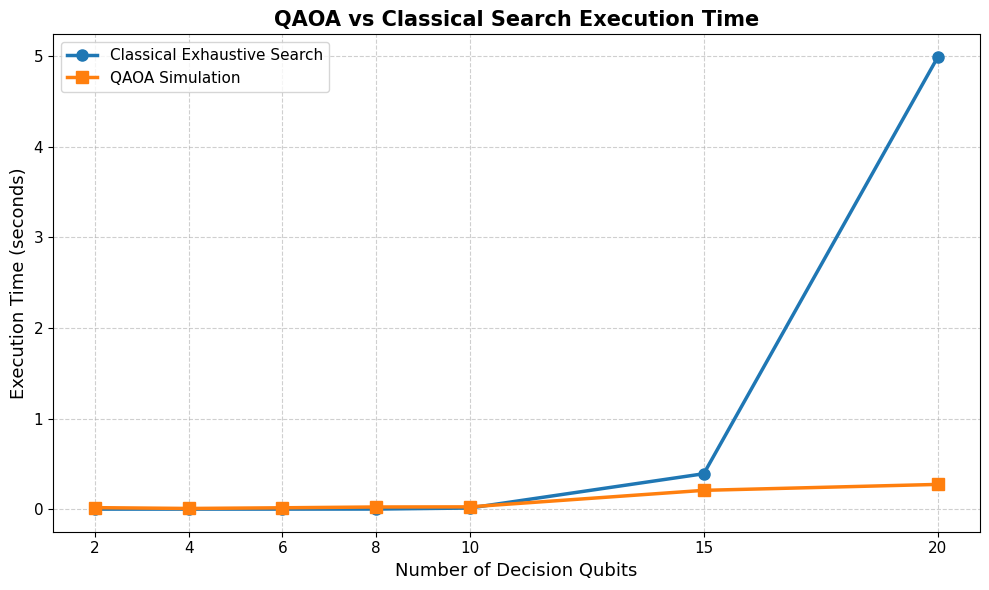


SCALING RESULTS
Qubits       Search Space       Classical Time       QAOA Time
---------------------------------------------------------------------------
2           4                 0.000034            0.016195
4           16                0.000055            0.007204
6           64                0.000217            0.014719
8           256               0.000753            0.023511
10          1024              0.012168            0.024863
15          32768             0.390485            0.207206
20          1048576           4.990690            0.272770


<Figure size 640x480 with 0 Axes>

In [ ]:
# ═══════════════════════════════════════════════════════════
# QAOA vs CLASSICAL SEARCH SCALING
# Combinatorial Search Space Analysis
# ═══════════════════════════════════════════════════════════

import itertools
import time
import matplotlib.pyplot as plt
import numpy as np

# ─── Different decision sizes ────────────────────────────
decision_sizes = [2, 4, 6, 8, 10, 15, 20]

classical_times = []
qaoa_times = []
search_spaces = []

# ─────────────────────────────────────────────────────────
# Reliability evaluation
# ─────────────────────────────────────────────────────────
def evaluate_bitstring_simple(bitstring):

    # dummy objective for timing experiment
    return bitstring.count('1')

# ─────────────────────────────────────────────────────────
# Main experiment
# ─────────────────────────────────────────────────────────
for n in decision_sizes:

    print("="*60)
    print(f"Running for {n} decision qubits")
    print("="*60)

    # ─── Search space ────────────────────────────────────
    space_size = 2**n
    search_spaces.append(space_size)

    # =====================================================
    # CLASSICAL EXHAUSTIVE SEARCH
    # =====================================================
    start_classical = time.time()

    best_score = -1

    for bits in itertools.product([0,1], repeat=n):

        bitstring = ''.join(map(str, bits))

        score = evaluate_bitstring_simple(bitstring)

        if score > best_score:
            best_score = score

    end_classical = time.time()

    classical_time = end_classical - start_classical
    classical_times.append(classical_time)

    # =====================================================
    # QAOA CIRCUIT
    # =====================================================
    qc = QuantumCircuit(n, n)

    gamma = 0.8
    beta  = 0.4

    # Initial superposition
    qc.h(range(n))

    # Cost Hamiltonian
    for i in range(n):
        qc.rz(2 * gamma, i)

    # Mixer
    for i in range(n):
        qc.rx(2 * beta, i)

    qc.measure(range(n), range(n))

    # ─── Run QAOA ────────────────────────────────────────
    start_qaoa = time.time()

    sim = AerSimulator(seed_simulator=42)

    result = sim.run(qc, shots=1024).result()

    counts = result.get_counts()

    end_qaoa = time.time()

    qaoa_time = end_qaoa - start_qaoa
    qaoa_times.append(qaoa_time)

    print(f"Search space: {space_size}")
    print(f"Classical time: {classical_time:.6f} sec")
    print(f"QAOA time: {qaoa_time:.6f} sec")

# ═══════════════════════════════════════════════════════════
# GRAPH 1 — EXECUTION TIME
# ═══════════════════════════════════════════════════════════

plt.figure(figsize=(10,6))

plt.plot(
    decision_sizes,
    classical_times,
    marker='o',
    linewidth=2.5,
    markersize=8,
    label='Classical Exhaustive Search'
)

plt.plot(
    decision_sizes,
    qaoa_times,
    marker='s',
    linewidth=2.5,
    markersize=8,
    label='QAOA Simulation'
)

plt.xlabel('Number of Decision Qubits', fontsize=13)

plt.ylabel('Execution Time (seconds)', fontsize=13)

plt.title(
    'QAOA vs Classical Search Execution Time',
    fontsize=15,
    fontweight='bold'
)

plt.xticks(decision_sizes, fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(fontsize=11)

plt.tight_layout()

plt.show()
plt.savefig("qaoa_complexity.png", dpi=600, bbox_inches='tight')


# ═══════════════════════════════════════════════════════════
# RESULTS TABLE
# ═══════════════════════════════════════════════════════════

print("\n" + "="*75)
print("SCALING RESULTS")
print("="*75)

print(f"{'Qubits':<12} {'Search Space':<18} "
      f"{'Classical Time':<20} {'QAOA Time'}")

print("-"*75)

for i in range(len(decision_sizes)):

    print(f"{decision_sizes[i]:<12}"
          f"{search_spaces[i]:<18}"
          f"{classical_times[i]:<20.6f}"
          f"{qaoa_times[i]:.6f}")

print("="*75)

# Conclusion

- Proposed realistic reliability-aware routing framework
- Incorporated memory decoherence and entanglement delay
- Implemented classical and quantum optimization methods
- Executed QAOA on IBM Quantum hardware
- Demonstrated realistic quantum-network routing optimization